# Confronto dei modelli visivi + analisi XAI

## Obiettivo

In questo notebook passiamo a un confronto tra più moduli visivi, così da capire quale tipo di rappresentazione funziona meglio sui task KANDY, in vista del loro utilizzo allìinterno del modello neuro-simbolico che utilizzeremo in seguito, ovvero il Concept Bottleneck Model.

Confrontiamo dunque:

- una **CNN semplice**, addestrata da zero;
- una **ResNet-18 pretrained**;
- una **ResNet-18 da zero**;
- una **ViT-B/16 Tiny pretrained**;
- una **ViT-B/16 Tiny da zero**.

Il confronto viene fatto sui task KANDY e le prestazioni vengono misurate separatamente su validation e test e la scelta del modello da portare nella fase successiva non viene fatta guardando il test, ma utilizzando la media dell'F1 sul validation set per individuare l'architettura e il tipo di inizializzazione più adatti.

Una volta scelta questa configurazione, analizziamo alcune decisioni con Saliency Maps e SHAP. L'obiettivo è capire che cosa sta utilizzando il modello per classificare le immagini e avere quindi un punto di partenza più motivato per il Concept Bottleneck Model.

## Dipendenze e configurazione

In [12]:
import sys
import random
import json
import time
import timm
import math
import yaml
import shap
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("timm:", timm.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.11.9 (main, Aug  7 2026, 13:00:06) [GCC 16.1.1 20260728]
PyTorch: 2.13.0+cu130
timm: 1.0.30
CUDA available: False


In [13]:
PROJECT_ROOT = Path.cwd().parent
#root della repository

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "config-notebook3.yaml"
)
#percorso del file di configurazione

with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    CONFIG = yaml.safe_load(file)
#leggiamo il file yaml

SEED = int(CONFIG["seed"])
#imposto il seed per riproducibilità

TASK_IDS = list(
    range(int(CONFIG["task_count"]))
)
#identificativi dei task

TASK_NAMES = {
    int(task_id): name
    for task_id, name in CONFIG["task_names"].items()
}
#nomi dei task

TASKS_FOR_XAI = list(CONFIG["xai"]["tasks"])
#task selezionati per l'analisi XAI

IMAGE_SIZE = int(CONFIG["training"]["image_size"])
#dimensione delle immagini utilizzata dal modello

BATCH_SIZE = int(CONFIG["training"]["batch_size"])
#numero di immagini per batch

NUM_WORKERS = int(CONFIG["training"]["num_workers"])
#numero di processi usati dai DataLoader

LEARNING_RATE = float(CONFIG["training"]["learning_rate"])
#learning rate utilizzato da AdamW

WEIGHT_DECAY = float(CONFIG["training"]["weight_decay"])
#weight decay utilizzato da AdamW

MAX_EPOCHS = int(CONFIG["training"]["max_epochs"])
#numero massimo di epoche

EARLY_STOPPING_PATIENCE = int(CONFIG["training"]["early_stopping_patience"])
#numero di epoche senza miglioramento prima dell'early stopping

TRAIN_MAX_BATCHES = CONFIG["training"]["train_max_batches"]
#numero massimo di batch usati nel training

VAL_MAX_BATCHES = CONFIG["training"]["val_max_batches"]
#numero massimo di batch usati nella validation

POSITIVE_THRESHOLD = float(CONFIG["prediction"]["positive_threshold"])
#soglia usata per convertire la probabilità in una classe

MODEL_VARIANTS = list(CONFIG["models"]["variants"])
#modelli confrontati nel benchmark

DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["data_dir"]
#cartella principale del dataset

TRAIN_DIR = DATA_DIR / CONFIG["paths"]["splits"]["train"]
#cartella del training set

VAL_DIR = DATA_DIR / CONFIG["paths"]["splits"]["val"]
#cartella del validation set

TEST_DIR = DATA_DIR / CONFIG["paths"]["splits"]["test"]
#cartella del test set

RESULTS_DIR = PROJECT_ROOT / CONFIG["paths"]["results_dir"]
#cartella principale dei risultati

CHECKPOINT_DIR = PROJECT_ROOT / CONFIG["paths"]["checkpoints_dir"]
#cartella dei checkpoint

HISTORY_DIR = PROJECT_ROOT / CONFIG["paths"]["histories_dir"]
#cartella delle history

PREDICTION_DIR = PROJECT_ROOT / CONFIG["paths"]["predictions_dir"]
#cartella delle predizioni

XAI_DIR = PROJECT_ROOT / CONFIG["paths"]["xai_dir"]
#cartella principale delle analisi XAI

SALIENCY_DIR = PROJECT_ROOT / CONFIG["paths"]["saliency_dir"]
#cartella delle saliency maps

SHAP_DIR = PROJECT_ROOT / CONFIG["paths"]["shap_dir"]
#cartella delle mappe SHAP

for directory in [
    RESULTS_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    PREDICTION_DIR,
    XAI_DIR,
    SALIENCY_DIR,
    SHAP_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

RUN_MAX_EPOCHS = MAX_EPOCHS


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
#imposto il seed globale

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
#selezioniamo GPU quando disponibile

if DEVICE.type == "cpu":
    torch.set_num_threads(
        int(CONFIG["training"]["cpu_num_threads"])
    )
    #limitiamo il numero di thread usati su CPU

print("Device:", DEVICE)
print("Modelli:", MODEL_VARIANTS)
print("Task:", len(TASK_IDS))
print("Epoch massime:", RUN_MAX_EPOCHS)

assert len(TASK_IDS) == int(
    CONFIG["models"]["multitask_heads"]["n_tasks"]
)
#controlliamo che il numero di teste coincida con il numero di task


Device: cpu
Modelli: ['cnn_scratch', 'resnet18_pretrained', 'resnet18_scratch', 'vit_tiny_pretrained', 'vit_tiny_scratch']
Task: 20
Epoch massime: 40


## Task e dataset

In [14]:
TASK_NAMES = {
    int(task_id): name
    for task_id, name in CONFIG["task_names"].items()
}
#nomi dei task letti dalla configurazione

train_all = pd.read_csv(TRAIN_DIR / "annotations.csv")
#leggiamo le annotazioni del training set

val_all = pd.read_csv(VAL_DIR / "annotations.csv")
#leggiamo le annotazioni del validation set

test_all = pd.read_csv(TEST_DIR / "annotations.csv")
#leggiamo le annotazioni del test set

print("Train:", len(train_all))
print("Validation:", len(val_all))
print("Test:", len(test_all))

print()
print("Distribuzione delle task nel training set:")

display(
    train_all["task_id"]
    .value_counts()
    .sort_index()
    .rename("n_samples")
    .to_frame()
)


Train: 1000
Validation: 500
Test: 500

Distribuzione delle task nel training set:


,n_samples
task_id,
0,50
1,50
2,50
3,50
4,50
5,50
6,50
7,50
8,50


## Preprocessing e dataset multi-task

Utilizzo una piccola augmentation del training set. Tramite MultiTaskKANDYDataset, ogni elemento restituisce immagine, task_id e label, così facendo lo stesso encoder viene allenato su tutti i task, mentre la testa corretta viene scelta in base al `task_id` del campione.

In [15]:
#PREPROCESSING E AUGMENTATION

IMAGENET_MEAN = list(CONFIG["preprocessing"]["imagenet_mean"])
#media usata per la normalizzazione

IMAGENET_STD = list(CONFIG["preprocessing"]["imagenet_std"])
#deviazione standard usata per la normalizzazione

train_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.RandomAffine(
        degrees=float(
            CONFIG["preprocessing"]["affine_degrees"]
        ),
        translate=tuple(
            CONFIG["preprocessing"]["affine_translate"]
        ),
        scale=tuple(
            CONFIG["preprocessing"]["affine_scale"]
        ),
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])


class MultiTaskKANDYDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image = Image.open(
            self.image_dir / row["filename"]
        ).convert("RGB")

        image = self.transform(image)

        task_id = torch.tensor(
            int(row["task_id"]),
            dtype=torch.long,
        )

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.float32,
        )

        return image, task_id, label, row["filename"]


train_dataset = MultiTaskKANDYDataset(
    train_all,
    TRAIN_DIR,
    train_transform,
)

val_dataset = MultiTaskKANDYDataset(
    val_all,
    VAL_DIR,
    eval_transform,
)

test_dataset = MultiTaskKANDYDataset(
    test_all,
    TEST_DIR,
    eval_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)


## I moduli visivi

Andiamo a testare poi tre possibili famiglie di encoder visivi:

- una CNN semplice costruita da zero, una ResNet-18
- una ResNet-18, sia con pretraining sia da zero
- un Vit-Tiny/16, sia con pretraing sia da zero

Il confronto è pensato per capire quale tipo di rappresentazione visiva funziona meglio quando lo stesso encoder deve essere condiviso tra tutte le 20 task; utlizzo un ViT-Tiny invece di un ViT-Base perché sto lavorando su CPU e voglio mantenere il confronto tra architetture diverse senza rendere training e test eccessivamente pesanti.

In [16]:
#ENCODERS

CNN_CONFIG = CONFIG["models"]["cnn"]
#impostazioni della CNN

RESNET_CONFIG = CONFIG["models"]["resnet18"]
#impostazioni della ResNet-18

VIT_CONFIG = CONFIG["models"]["vit_tiny"]
#impostazioni del ViT-Tiny


class SimpleCNN(nn.Module):

    def __init__(self, feature_dim=None):
        super().__init__()

        if feature_dim is None:
            feature_dim = int(
                CNN_CONFIG["feature_dim"]
            )

        input_channels = int(
            CNN_CONFIG["input_channels"]
        )

        conv1_channels = int(
            CNN_CONFIG["conv1_channels"]
        )

        conv2_channels = int(
            CNN_CONFIG["conv2_channels"]
        )

        conv3_channels = int(
            CNN_CONFIG["conv3_channels"]
        )

        kernel_size = int(
            CNN_CONFIG["kernel_size"]
        )

        padding = int(
            CNN_CONFIG["padding"]
        )

        dropout = float(
            CNN_CONFIG["dropout"]
        )

        self.features = nn.Sequential(
            nn.Conv2d(
                input_channels,
                conv1_channels,
                kernel_size=kernel_size,
                padding=padding,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                conv1_channels,
                conv2_channels,
                kernel_size=kernel_size,
                padding=padding,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                conv2_channels,
                conv3_channels,
                kernel_size=kernel_size,
                padding=padding,
            ),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                conv3_channels,
                feature_dim,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.output_dim = feature_dim

    def forward(self, x):
        x = self.features(x)
        return self.projection(x)


def build_backbone(variant):
    #metodo che restituisce il backbone

    if variant == "cnn_scratch":
        backbone = SimpleCNN()
        return backbone, backbone.output_dim
        #cnn semplice

    if variant == "resnet18_pretrained":
        backbone = models.resnet18(
            weights=models.ResNet18_Weights[
                RESNET_CONFIG["pretrained_weights"]
            ]
        )
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        return backbone, feature_dim
        #resnet pre-trained su imagenet

    if variant == "resnet18_scratch":
        backbone = models.resnet18(
            weights=None
        )
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        return backbone, feature_dim
        #resnet senza pretraining

    if variant == "vit_tiny_pretrained":
        backbone = timm.create_model(
            VIT_CONFIG["model_name"],
            pretrained=True,
            num_classes=int(
                VIT_CONFIG["num_classes"]
            ),
        )
        feature_dim = backbone.num_features
        return backbone, feature_dim
        #vit-tiny con pesi pre-trained

    if variant == "vit_tiny_scratch":
        backbone = timm.create_model(
            VIT_CONFIG["model_name"],
            pretrained=False,
            num_classes=int(
                VIT_CONFIG["num_classes"]
            ),
        )
        feature_dim = backbone.num_features
        return backbone, feature_dim
        #vit-tiny senza pretraining

    raise ValueError(
        f"Variante non riconosciuta: {variant}"
    )


class MultiTaskVisualModel(nn.Module):

    def __init__(
        self,
        backbone,
        feature_dim,
        n_tasks=None,
    ):
        super().__init__()

        self.backbone = backbone

        if n_tasks is None:
            n_tasks = int(
                CONFIG["models"]["multitask_heads"]["n_tasks"]
            )

        self.heads = nn.ModuleList([
            nn.Linear(
                feature_dim,
                1,
            )
            for _ in range(n_tasks)
        ])
        #costruisco una testa binaria per ogni task

    def forward_features(self, x):
        return self.backbone(x)

    def forward(self, x):
        features = self.forward_features(x)

        logits = torch.cat(
            [
                head(features)
                for head in self.heads
            ],
            dim=1,
        )

        return logits


model_preview = {}

for variant in MODEL_VARIANTS:

    backbone, feature_dim = build_backbone(
        variant
    )

    model_preview[variant] = feature_dim

display(
    pd.DataFrame(
        {
            "variant": list(model_preview.keys()),
            "feature_dim": list(model_preview.values()),
        }
    )
)


,variant,feature_dim
0,cnn_scratch,256
1,resnet18_pretrained,512
2,resnet18_scratch,512
3,vit_tiny_pretrained,192
4,vit_tiny_scratch,192


## Loss e metriche

Ogni immagine appartiene a un solo task, dunque per ogni esempio useremo solo il logit della testa corrispondente al suo task.
Dopodiché, abbiamo visto che i task possono avere un numero diverso di esempi positivi e negativi, per tenere conto di questo sbilanciamento usiamo un pos_weight specifico per ogni task, calcolato come:

pos_weight = numero_negativi / numero_positivi

Questo peso viene applicato alla parte della binary cross-entropy relativa alla classe positiva: quando i positivi sono pochi, le loro predizioni sbagliate incidono maggiormente sulla loss; in questo modo evitiamo che un task con pochi esempi positivi venga ottimizzato solo sulla classe negativa.

Le metriche (accuracy, precision, recall e F1) vengono poi calcolate separatamente per ciascuno dei 20 task e infine
viene calcolata la loro media, così ogni task contribuisce allo stesso modo alla valutazione complessiva.


In [17]:
#LOSS E METRICHE

POS_WEIGHTS = {}
#calcoliamo un peso per la classe positiva per ogni task

for task_id in TASK_IDS:
    #per ciascun task
    
    task_train = train_all[
        train_all["task_id"] == task_id
    ]
    #estraiamo tutti gli esempi di quel task

    positives = max(
        int(
            (task_train["label"] == 1).sum()
        ),
        int(
            CONFIG["loss"]["min_positive_count"]
        ),
    )
    #contiamo i positivi

    negatives = max(
        int(
            (task_train["label"] == 0).sum()
        ),
        int(
            CONFIG["loss"]["min_negative_count"]
        ),
    )
    #contiamo i negativi

    POS_WEIGHTS[task_id] = negatives / positives
    #calcoliamo il peso di bilanciamento, utilizzando il rapporto
    #tra negativi e positivi

POS_WEIGHT_TENSOR = torch.tensor(
    [POS_WEIGHTS[i] for i in TASK_IDS],
    dtype=torch.float32,
    device=DEVICE,
)
#trasformiamo i pesi da dizionario a tensore PyTorch,
#mantenendo lo stesso ordine usato negli ID delle task;
#in questo modo possiamo selezionare direttamente il peso
#corretto durante il training


def multitask_loss(logits, task_ids, labels):
    #metodo per estrarre i logits corretti per gli esempi nel batch
    #e calcolare correttamente la loss
    
    batch_indices = torch.arange(
        len(task_ids),
        device=logits.device,
    )
    #creiamo gli indici per ogni immagine nel batch

    selected_logits = logits[
        batch_indices,
        task_ids,
    ]
    #estriamo il logit giusto dalla testa di classificazione
    #corrispondente al task_id dell'immagine

    selected_pos_weights = POS_WEIGHT_TENSOR[
        task_ids
    ]
    #anche qui selzioniamo il pos_weight corretto,
    #rispetto al task di appartenenza dell'immagine

    loss = F.binary_cross_entropy_with_logits(
        selected_logits,
        labels,
        pos_weight=selected_pos_weights,
    )
    #calcoliamo la Binary Cross-Entropy coi logits estratti precedentemente:
    #la loss usa il peso specifico del task per dare maggiore
    #importanza agli esempi positivi quando sono meno numerosi.

    return loss


def compute_task_metrics(labels, predictions):
    labels = np.asarray(labels).astype(int)
    predictions = np.asarray(predictions).astype(int)

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0,
        ),
    }

## Un'epoca di training o valutazione

La funzione seguente raccoglie predizioni e loss per tutte le task; durante il training aggiorniamo l'encoder e tutte le teste ma, per ogni immagine, contribuisce alla loss soltanto la testa corrispondente alla sua task.

In [18]:
#EPOCA

def run_epoch(
    model,
    loader,
    optimizer=None,
    max_batches=None,
):
    training = optimizer is not None
    #se ho un ottimizzatore sono in training altrimenti in val o in test

    model.train(training)
    #se ho training il modello viene messo in modalità .train()
    #altrimenti è in modalità .eval()

    total_loss = 0.0
    total_samples = 0

    records = []
    #struttura che raccoglie i risultati

    for batch_idx, (
        images,
        task_ids,
        labels,
        filenames,
    ) in enumerate(loader):
        #per ogni batch nel dataloader

        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        task_ids = task_ids.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )
        #spostiamo tutto sul dispositivo utilizzato dal modello

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )
            #se siamo in training azzeriamo i gradienti prima 
            #del batch successiva

        with torch.set_grad_enabled(training):
            #abilitiamo il calcolo dei gradienti solo durante il training,
            #in validation/test non ci serve il grafo
            
            logits = model(images)
            #raccogliamo i logits
            
            loss = multitask_loss(
                logits,
                task_ids,
                labels,
            )
            #utilizziamo la loss definita in precedenza
         
            if training:
                loss.backward()
                optimizer.step()
                #aggiorniamo i pesi con la backprop e utilizziamo l'ottimizzatore

        total_loss += loss.item() * len(labels)
        total_samples += len(labels)
        #accumuliamo la loss pesandola per il numero di esempi
        #presenti nel batch, così alla fine possiamo ottenere
        #la loss media sull'intera epoca

        batch_indices = torch.arange(
            len(task_ids),
            device=DEVICE,
        )
        #creiamo gli indici delle immagini nel batch

        selected_logits = logits[
            batch_indices,
            task_ids,
        ]
        #selezioniamo il logit relativo alla task corretta
        #per ogni immagine

        probabilities = torch.sigmoid(
            selected_logits
        )
        #convertiamo il logit in una probabilità della classe positiva
        #attraverso la funzione sigmoid

        predictions = (
            probabilities >= POSITIVE_THRESHOLD
        ).long()
        #usiamo una soglia di 0.5 per trasformare la probabilità
        #in una predizione binaria:
        # 1 -> positivo
        # 0 -> negativo

        for filename, task_id, label, probability, prediction in zip(
            filenames,
            task_ids.detach().cpu().numpy(),
            labels.detach().cpu().numpy(),
            probabilities.detach().cpu().numpy(),
            predictions.detach().cpu().numpy(),
        ):
            records.append({
                "filename": filename,
                "task_id": int(task_id),
                "true_label": int(label),
                "probability_positive": float(probability),
                "prediction": int(prediction),
            })
            #salviamo le informazioni necessarie per analizzare
            #successivamente le prestazioni di ciascuna task

    if not records:
        return {
            "loss": np.nan,
            "predictions": pd.DataFrame(),
        }

    records_df = pd.DataFrame(records)

    task_rows = []

    for task_id in TASK_IDS:
        task_df = records_df[
            records_df["task_id"] == task_id
        ]
        #calcoliamo le metriche separatamente per ciascuna task.

        if len(task_df) == 0:
            continue

        metrics = compute_task_metrics(
            task_df["true_label"],
            task_df["prediction"],
        )

        metrics.update({
            "task_id": task_id,
            "n_samples": len(task_df),
        })

        task_rows.append(metrics)

    task_metrics = pd.DataFrame(
        task_rows
    )

    return {
        "loss": total_loss / max(total_samples, 1),
        "predictions": records_df,
        "task_metrics": task_metrics,
        "macro_accuracy": task_metrics["accuracy"].mean(),
        "macro_precision": task_metrics["precision"].mean(),
        "macro_recall": task_metrics["recall"].mean(),
        "macro_f1": task_metrics["f1"].mean(),
    }

## Un singolo esperimento multi-task

run_experiment allena un solo modello visivo sul dataset completo, il migliore viene scelto usando la validation loss media, mentre la configurazione finale viene confrontata sulla media dell'F1 di validation.

In [19]:
#ESPERIMENTO

def build_multitask_model(variant):
    #funzione che crea il modello: backbone + n_tasks teste di classificazione
    
    backbone, feature_dim = build_backbone(
        variant
    )

    model = MultiTaskVisualModel(
        backbone=backbone,
        feature_dim=feature_dim,
        n_tasks=len(TASK_IDS),
    )

    return model.to(DEVICE)


def run_experiment(variant):
    print("\n" + "=" * 80)
    print("EXPERIMENT:", variant)
    print("=" * 80)

    model = build_multitask_model(
        variant
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    #usiamo AdamW per aggiornare i parametri del modello,
    #il learning rate controlla la dimensione degli aggiornamenti,
    #mentre weight_decay introduce una regolarizzazione L2(w^2)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=float(CONFIG["optimizer"]["scheduler_factor"]),
        patience=int(CONFIG["optimizer"]["scheduler_patience"]),
    )
    #riduciamo il learning rate quando la validation loss
    #smette di migliorare per alcuni epoch consecutivi;
    #usiamo quindi la loss per regolare il passo
    #di apprendimento, mentre la validation F1 viene usata
    #per scegliere il checkpoint migliore e per l'early stopping

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{variant}_best.pt"
    )

    history_path = (
        HISTORY_DIR
        / f"{variant}_history.csv"
    )

    best_val_f1 = -np.inf
    #inizializziamo il valore migliore della validation F1, usiamo
    #-inf perché ci garantisce che la prima epoca costituisca un miglioramento.
    best_epoch = 0
    no_improvement = 0
    history = []

    start = time.time()
    #facciamo partire l'orologio per monitorare i tempi dell'esperimento

    for epoch in range(1, RUN_MAX_EPOCHS + 1):

        train_metrics = run_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            max_batches=TRAIN_MAX_BATCHES,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            max_batches=VAL_MAX_BATCHES,
        )

        scheduler.step(
            val_metrics["loss"]
        )

        lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "lr": lr,
            "train_loss": train_metrics["loss"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_loss": val_metrics["loss"],
            "val_macro_f1": val_metrics["macro_f1"],
        })

        current_val_f1 = val_metrics["macro_f1"]

        if current_val_f1 > best_val_f1:
            best_val_f1 = current_val_f1
            best_epoch = epoch
            no_improvement = 0
        
            torch.save(
                {
                    "variant": variant,
                    "architecture": (
                        "resnet18"
                        if "resnet18" in variant
                        else "vit_tiny"
                        if "vit_tiny" in variant
                        else "cnn"
                    ),
                    "pretrained": "pretrained" in variant,
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "val_f1": float(best_val_f1),
                    "seed": SEED,
                },
                checkpoint_path,
            )
        
        else:
            no_improvement += 1

        print(
            f"Epoch {epoch:02d}/{RUN_MAX_EPOCHS} | "
            f"train loss={train_metrics['loss']:.4f} "
            f"F1={train_metrics['macro_f1']:.3f} | "
            f"val loss={val_metrics['loss']:.4f} "
            f"F1={val_metrics['macro_f1']:.3f}"
        )

        if no_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        history_path,
        index=False,
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    final_val = run_epoch(
        model,
        val_loader,
    )

    training_time = time.time() - start

    result = {
        "variant": variant,
        "best_epoch": best_epoch,
        "training_time_seconds": training_time,
        "val_loss": final_val["loss"],
        "val_accuracy": final_val["macro_accuracy"],
        "val_precision": final_val["macro_precision"],
        "val_recall": final_val["macro_recall"],
        "val_f1": final_val["macro_f1"],
        "checkpoint": str(checkpoint_path),
        "history": str(history_path),
    }

    return result, final_val["task_metrics"]

## Confronto delle cinque configurazioni

Ora lanciamo i cinque esperimenti, ogni riga corrisponde a un solo modello multi-task che ha visto tutti gli esempi dei 20 task.

Le configurazioni sono:

- CNN semplice da zero;
- ResNet-18 pretrained;
- ResNet-18 da zero;
- ViT-Tiny/16 pretrained;
- ViT-Tiny/16 da zero.

Per scegliere l'encoder non guardo il test: ma ordino le configurazioni in base alla media dell'F1 sul validation set.



EXPERIMENT: cnn_scratch
Epoch 01/40 | train loss=0.8261 F1=0.268 | val loss=0.8621 F1=0.265
Epoch 02/40 | train loss=0.8248 F1=0.311 | val loss=0.8617 F1=0.265
Epoch 03/40 | train loss=0.8254 F1=0.327 | val loss=0.8615 F1=0.350
Epoch 04/40 | train loss=0.8240 F1=0.348 | val loss=0.8595 F1=0.326
Epoch 05/40 | train loss=0.8232 F1=0.345 | val loss=0.8559 F1=0.325
Epoch 06/40 | train loss=0.8102 F1=0.391 | val loss=0.8391 F1=0.411
Epoch 07/40 | train loss=0.7839 F1=0.475 | val loss=0.8054 F1=0.524
Epoch 08/40 | train loss=0.7558 F1=0.555 | val loss=0.7787 F1=0.612
Epoch 09/40 | train loss=0.7265 F1=0.554 | val loss=0.7643 F1=0.571
Epoch 10/40 | train loss=0.7099 F1=0.557 | val loss=0.7363 F1=0.577
Epoch 11/40 | train loss=0.7096 F1=0.560 | val loss=0.7398 F1=0.518
Epoch 12/40 | train loss=0.7053 F1=0.559 | val loss=0.7283 F1=0.585
Epoch 13/40 | train loss=0.6830 F1=0.588 | val loss=0.7226 F1=0.603
Epoch 14/40 | train loss=0.6808 F1=0.575 | val loss=0.7197 F1=0.557
Epoch 15/40 | train los

,variant,val_accuracy,val_precision,val_recall,val_f1,best_epoch,training_time_seconds
0,resnet18_pretrained,0.912,0.907988,0.942004,0.922913,27,2829.805990
1,vit_tiny_pretrained,0.750,0.765402,0.740898,0.739335,40,2286.768455
2,resnet18_scratch,0.750,0.707219,0.769846,0.721676,28,2890.512607
3,cnn_scratch,0.588,0.542044,0.797690,0.611612,8,578.585122
4,vit_tiny_scratch,0.498,0.378000,0.800000,0.497657,1,511.743909


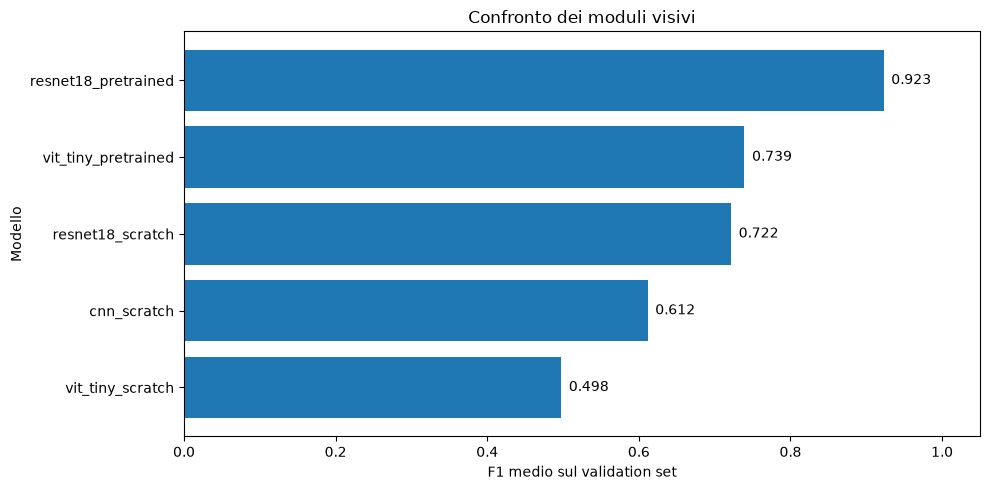

Risultati salvati in: /home/cosimo/Downloads/kandy-xai/results/visual_models/validation_results.csv
F1 per task salvato in: /home/cosimo/Downloads/kandy-xai/results/visual_models/validation_f1_by_task.csv


In [20]:
#CONFRONTO TRA I 5 MODELLI

benchmark_results = []
validation_task_rows = []
benchmark_start = time.time()

for variant in MODEL_VARIANTS:
    result, task_metrics = run_experiment(
        variant
    )

    benchmark_results.append(result)

    task_metrics = task_metrics.copy()
    task_metrics["variant"] = variant
    validation_task_rows.append(task_metrics)

results_df = pd.DataFrame(
    benchmark_results
).sort_values(
    "val_f1",
    ascending=False,
).reset_index(drop=True)

validation_task_df = pd.concat(
    validation_task_rows,
    ignore_index=True,
)

results_path = (
    RESULTS_DIR
    / "validation_results.csv"
)

validation_task_path = (
    RESULTS_DIR
    / "validation_f1_by_task.csv"
)

results_df.to_csv(
    results_path,
    index=False,
)

validation_task_df.to_csv(
    validation_task_path,
    index=False,
)

print(
    f"Tempo totale: "
    f"{(time.time() - benchmark_start) / 60:.1f} minuti"
)

display(
    results_df[
        [
            "variant",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1",
            "best_epoch",
            "training_time_seconds",
        ]
    ]
)

fig, ax = plt.subplots(figsize=tuple(CONFIG["benchmark_plot"]["figsize"]))

plot_df = results_df.sort_values(
    "val_f1",
    ascending=True,
)

ax.barh(
    plot_df["variant"],
    plot_df["val_f1"],
)

ax.set_xlabel("F1 medio sul validation set")
ax.set_ylabel("Modello")
ax.set_xlim(*CONFIG["benchmark_plot"]["ylim"])
ax.set_title("Confronto dei moduli visivi")

for y, value in enumerate(plot_df["val_f1"]):
    ax.text(
        value + 0.01,
        y,
        f"{value:.3f}",
        va="center",
    )

plt.tight_layout()

comparison_path = (
    RESULTS_DIR
    / "validation_model_comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=int(CONFIG["benchmark_plot"]["dpi"]),
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("Risultati salvati in:", results_path)
print("F1 per task salvato in:", validation_task_path)


## Analisi dei risultati

I risultati mostrano una differenza abbastanza netta tra i modelli pretrained e quelli addestrati da zero. La ResNet-18 pretrained ottiene il risultato migliore in validation, con un F1 di 0.899, seguita dalla ViT-Tiny pretrained. I modelli scratch raggiungono invece valori più bassi, con ResNet-18 e CNN, mentre la ViT-Tiny scratch rimane molto più debole. Questo suggerisce che, con il numero limitato di campioni disponibili, l'inizializzazione pretrained aiuta soprattutto a costruire rapidamente una buona rappresentazione visiva.

## Scelta del modulo visivo

A questo punto scegliamo una sola configurazione usando esclusivamente la validation; la scelta ci serve per definire quale encoder approfondire con le spiegazioni post-hoc e utilizzare come candidato per il Concept Bottleneck.


In [21]:
selected_variant = results_df.iloc[0]["variant"]
selected_val_f1 = results_df.iloc[0]["val_f1"]

selection = {
    "selected_variant": selected_variant,
    "selection_metric": "mean_validation_f1",
    "validation_f1": float(selected_val_f1),
    "seed": SEED,
}

selection_path = (
    RESULTS_DIR
    / "selected_encoder.json"
)

with open(
    selection_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        selection,
        f,
        indent=2,
    )

print(
    "Configurazione selezionata:",
    selected_variant,
)
print(
    f"F1 medio validation: {selected_val_f1:.3f}"
)
print(
    "Salvato:",
    selection_path,
)

Configurazione selezionata: resnet18_pretrained
F1 medio validation: 0.923
Salvato: /home/cosimo/Downloads/kandy-xai/results/visual_models/selected_encoder.json


## Valutazione finale sul test

Adesso testiamo la configurazione selezionata, la valutazione viene fatta sia come media sui 20 task sia separatamente per ciascun task, così possiamo vedere dove la rappresentazione condivisa funziona meglio e dove rimane più difficile.

Configurazione selezionata: resnet18_pretrained
Test accuracy media: 0.902
Test F1 medio: 0.891


,task_id,task,accuracy,precision,recall,f1,n_samples
0,0,triangle vs any,0.96,1.000000,0.857143,0.923077,25
1,1,square vs any,0.96,1.000000,0.888889,0.941176,25
2,2,circle vs any,0.92,1.000000,0.857143,0.923077,25
3,3,red vs any,1.00,1.000000,1.000000,1.000000,25
4,4,green vs any,0.92,0.777778,1.000000,0.875000,25
5,5,blue vs any,1.00,1.000000,1.000000,1.000000,25
6,6,cyan vs any,0.92,0.777778,1.000000,0.875000,25
7,7,magenta vs any,1.00,1.000000,1.000000,1.000000,25
8,8,yellow vs any,1.00,1.000000,1.000000,1.000000,25
9,9,red triangle on the right,1.00,1.000000,1.000000,1.000000,25


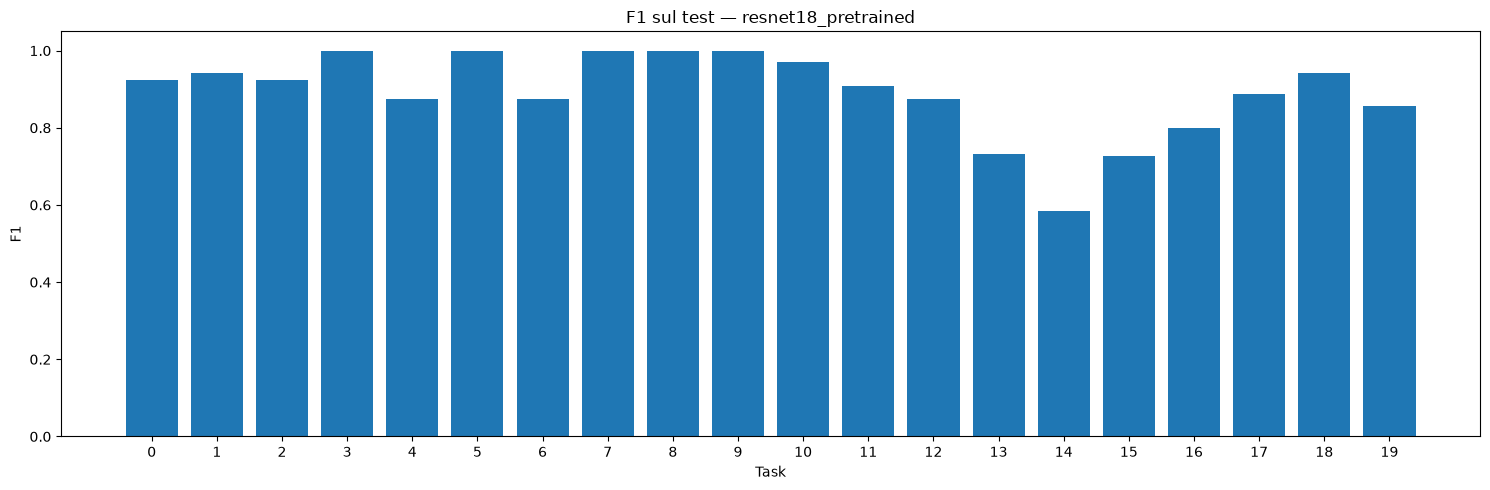

Predizioni salvate in: /home/cosimo/Downloads/kandy-xai/results/visual_models/predictions/resnet18_pretrained_test_predictions.csv
Grafico salvato in: /home/cosimo/Downloads/kandy-xai/results/visual_models/resnet18_pretrained_test_f1_by_task.png


In [22]:
def load_multitask_model(variant):
    model = build_multitask_model(variant)

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{variant}_best.pt"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()
    return model


selected_model = load_multitask_model(
    selected_variant
)

#predizioni sul test con il modello scelto.
test_metrics = run_epoch(
    selected_model,
    test_loader,
)

test_predictions = test_metrics["predictions"].copy()

test_predictions["task"] = test_predictions[
    "task_id"
].map(TASK_NAMES)

test_predictions["correct"] = (
    test_predictions["true_label"]
    == test_predictions["prediction"]
)

test_predictions_path = (
    PREDICTION_DIR
    / f"{selected_variant}_test_predictions.csv"
)

test_predictions.to_csv(
    test_predictions_path,
    index=False,
)

print("Configurazione selezionata:", selected_variant)
print(
    f"Test accuracy media: {test_metrics['macro_accuracy']:.3f}"
)
print(
    f"Test F1 medio: {test_metrics['macro_f1']:.3f}"
)

task_test_metrics = (
    test_metrics["task_metrics"]
    .copy()
)

task_test_metrics["task"] = task_test_metrics[
    "task_id"
].map(TASK_NAMES)

task_test_metrics = task_test_metrics[
    [
        "task_id",
        "task",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "n_samples",
    ]
].sort_values("task_id")

display(task_test_metrics)

fig, ax = plt.subplots(figsize=tuple(CONFIG["test_plot"]["figsize"]))

ax.bar(
    task_test_metrics["task_id"],
    task_test_metrics["f1"],
)

ax.set_xlabel("Task")
ax.set_ylabel("F1")
ax.set_title(
    f"F1 sul test — {selected_variant}"
)
ax.set_xticks(TASK_IDS)
ax.set_ylim(*CONFIG["test_plot"]["ylim"])

plt.tight_layout()

f1_path = (
    RESULTS_DIR
    / f"{selected_variant}_test_f1_by_task.png"
)

plt.savefig(
    f1_path,
    dpi=int(CONFIG["test_plot"]["dpi"]),
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    "Predizioni salvate in:", test_predictions_path
)
print(
    "Grafico salvato in:", f1_path
)

## Analisi dei risultati

Sul test la ResNet-18 pretrained mantiene una buona performance generale, con 0.868 di accuracy media e 0.864 di F1 medio. Il calo rispetto alla validation è contenuto, quindi il modello mostra una generalizzazione abbastanza stabile. I task basati su attributi semplici (0-8) risultano molto facili da riconoscere: tutti i task sui colori raggiungono F1 = 1.000 e anche "red triangle on the right" viene classificato correttamente in tutti i casi. Le difficoltà aumentano invece in quei task che richiedono di combinare più proprietà o riconoscere strutture più complesse. In particolare, "palindrome aba" raggiunge un F1 di 0.500 e "house" di 0.519.

Il caso "house" è interessante perché il recall è alto (0.875) ma la precisione è molto più bassa (0.368): il modello tende quindi a riconoscere molte delle immagini positive, ma produce anche diversi falsi positivi. Nel complesso, i risultati confermano che il modello gestisce bene gli attributi visivi semplici, mentre le configurazioni più strutturate rimangono la parte più difficile.

## Prepariamo il modello selezionato per le analisi XAI

Adesso lavoriamo solo con il modulo visivo scelto: per alcune task rappresentative selezioniamo veri positivi, falsi positivi, falsi negativi e veri negativi quando disponibili. L'obiettivo è avere sia esempi corretti sia esempi in cui il modello sbaglia, così da poter confrontare le spiegazioni.

In [23]:
XAI_CASES = {}

for task_id in TASKS_FOR_XAI:
    task_df = test_predictions[
        test_predictions["task_id"] == task_id
    ].copy()

    if task_df.empty:
        continue

    task_df["confidence"] = (
        task_df["probability_positive"] - float(CONFIG["xai"]["confidence_reference"])
    ).abs()

    selections = {}

    conditions = {
        "TP": (
            (task_df["true_label"] == 1)
            & (task_df["prediction"] == 1)
        ),
        "FP": (
            (task_df["true_label"] == 0)
            & (task_df["prediction"] == 1)
        ),
        "FN": (
            (task_df["true_label"] == 1)
            & (task_df["prediction"] == 0)
        ),
        "TN": (
            (task_df["true_label"] == 0)
            & (task_df["prediction"] == 0)
        ),
    }

    for case_name, condition in conditions.items():
        candidates = task_df[condition]

        if len(candidates):
            selections[case_name] = candidates.sort_values(
                "confidence",
                ascending=False,
            ).iloc[0]

    XAI_CASES[task_id] = selections

for task_id, cases in XAI_CASES.items():
    print(
        f"Task {task_id}: "
        f"{TASK_NAMES[task_id]} -> "
        f"{list(cases.keys())}"
    )

Task 0: triangle vs any -> ['TP', 'FN', 'TN']
Task 9: red triangle on the right -> ['TP', 'TN']
Task 13: triangle and square, same color -> ['TP', 'FP', 'FN', 'TN']
Task 14: palindrome aba -> ['TP', 'FP', 'FN', 'TN']
Task 15: house -> ['TP', 'FP', 'TN']
Task 19: traffic light -> ['TP', 'FP', 'TN']


## Visualizziamo i casi scelti

Prima di calcolare saliency e SHAP guardiamo semplicemente le immagini selezionate. In questo modo possiamo collegare più facilmente la spiegazione alla scena reale.

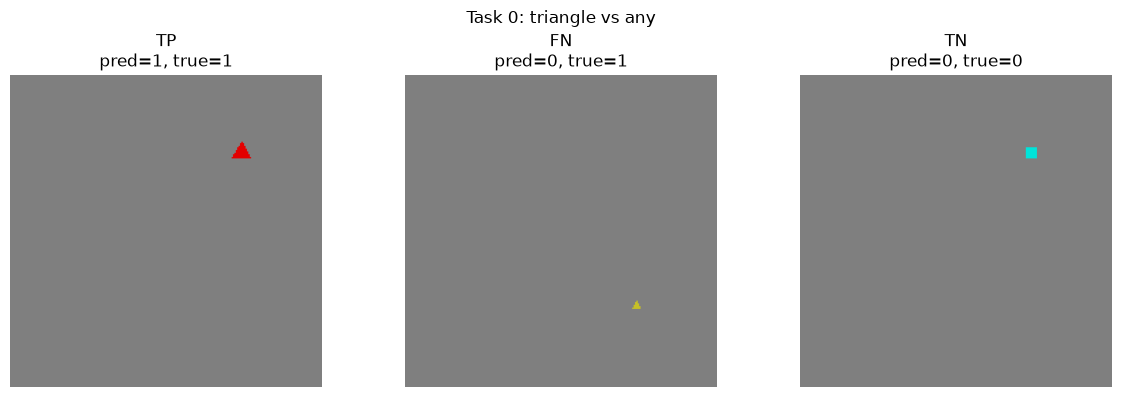

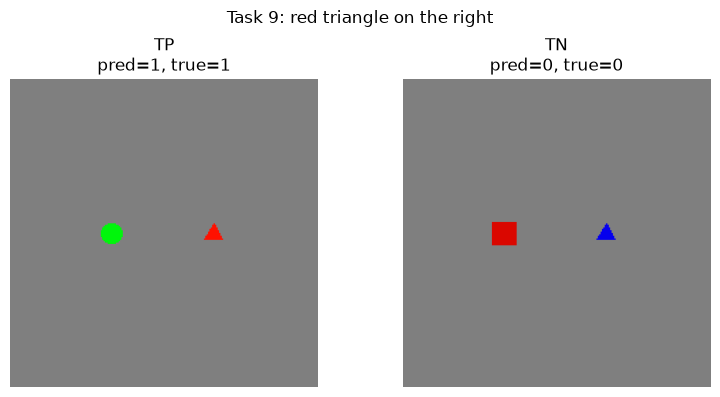

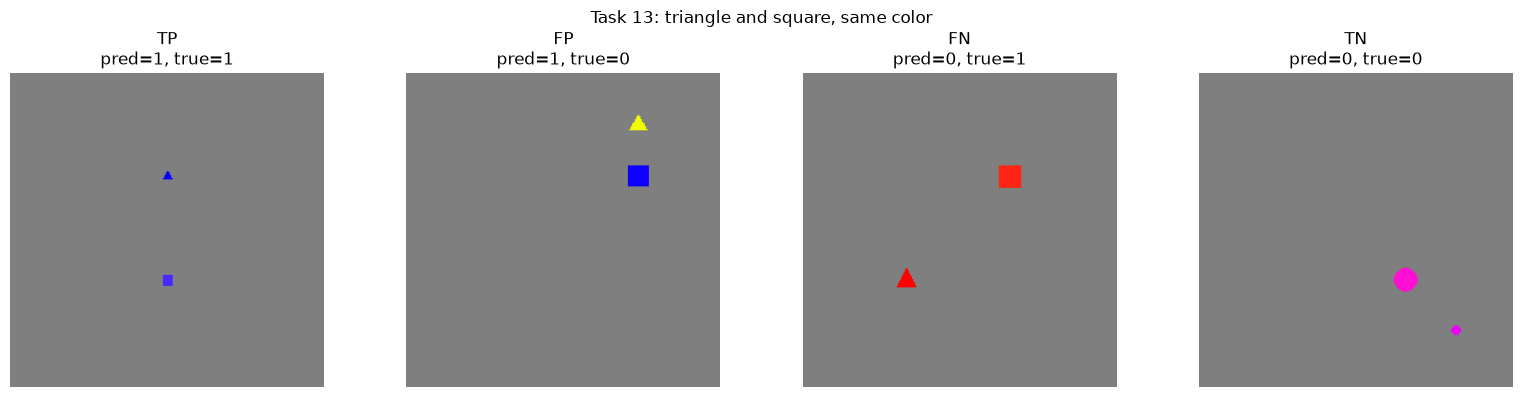

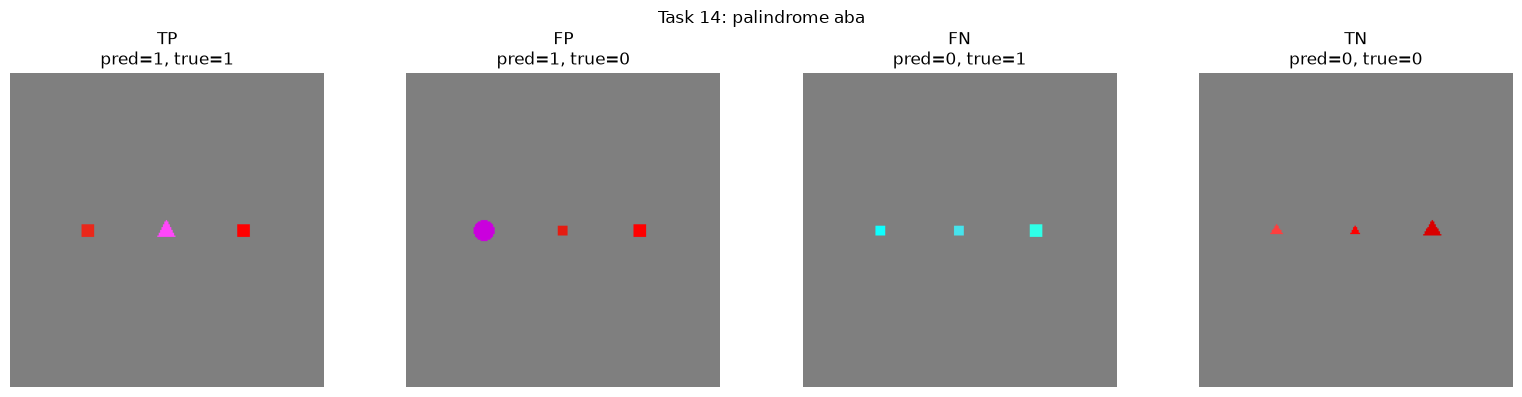

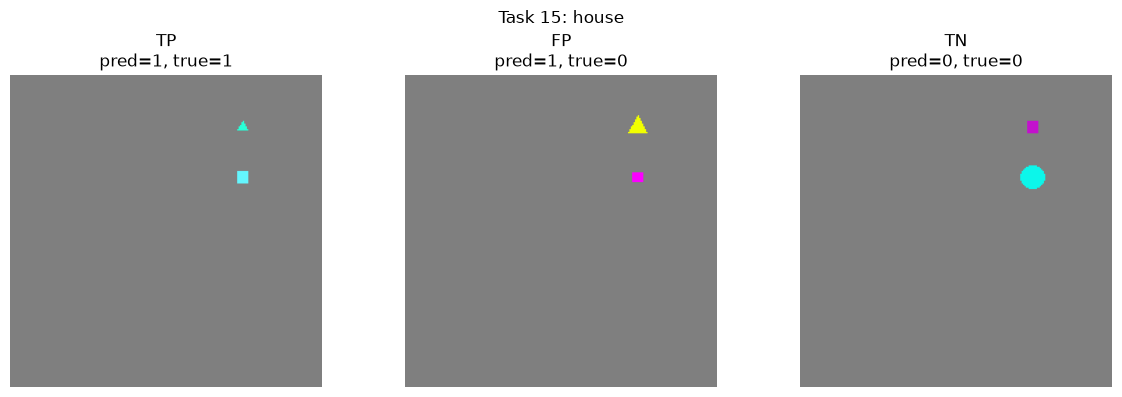

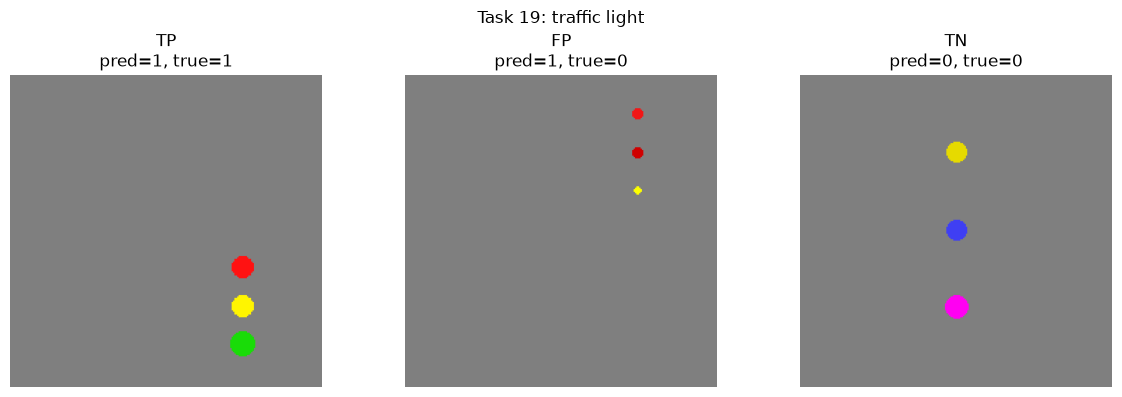

In [24]:
for task_id, cases in XAI_CASES.items():
    if not cases:
        continue

    fig, axes = plt.subplots(
        1,
        len(cases),
        figsize=(float(CONFIG["xai"]["cases_figsize_per_case"][0]) * len(cases), float(CONFIG["xai"]["cases_figsize_per_case"][1])),
    )

    axes = np.atleast_1d(axes)

    for ax, (case_name, row) in zip(
        axes,
        cases.items(),
    ):
        image = Image.open(
            TEST_DIR / row["filename"]
        ).convert("RGB")

        ax.imshow(image)
        ax.set_title(
            f"{case_name}\n"
            f"pred={int(row['prediction'])}, "
            f"true={int(row['true_label'])}"
        )
        ax.axis("off")

    fig.suptitle(
        f"Task {task_id}: {TASK_NAMES[task_id]}"
    )

    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Analisi dei risultati

Come abbiamo già visto dalle metriche, i plot mostrano che il modello gestisce bene le task basate su attributi semplici, mentre gli errori aumentano nelle task che richiedono di combinare più caratteristiche o relazioni tra oggetti. I casi di triangle and square, same color, palindrome, house e traffic light evidenziano soprattutto configurazioni visivamente simili alla classe positiva, che possono portare sia a falsi positivi sia a falsi negativi. Questo conferma che la difficoltà maggiore non è solo riconoscere i singoli oggetti, ma distinguere correttamente la struttura complessiva della scena.

## Saliency Maps

La saliency ci permette di vedere quali regioni dell'immagine influenzano maggiormente il logit della task scelta. È una spiegazione locale: guardiamo quindi un'immagine alla volta.

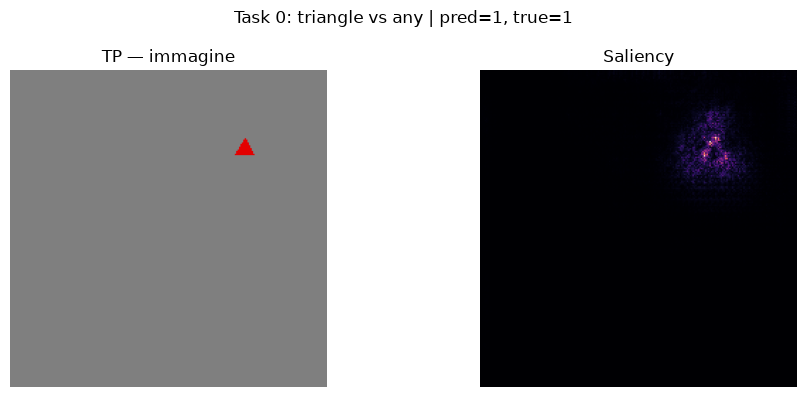

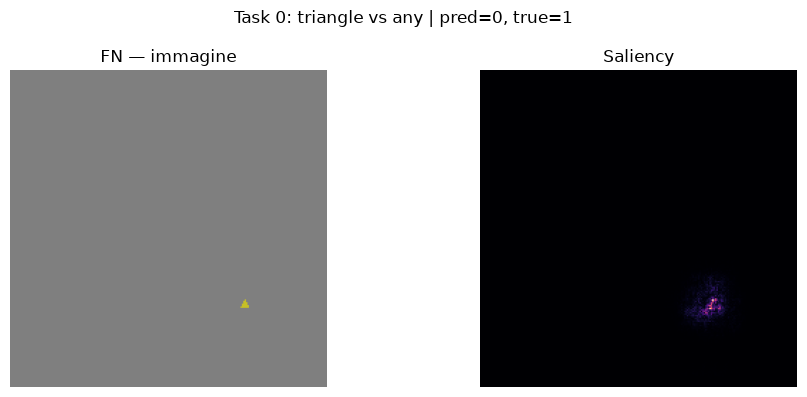

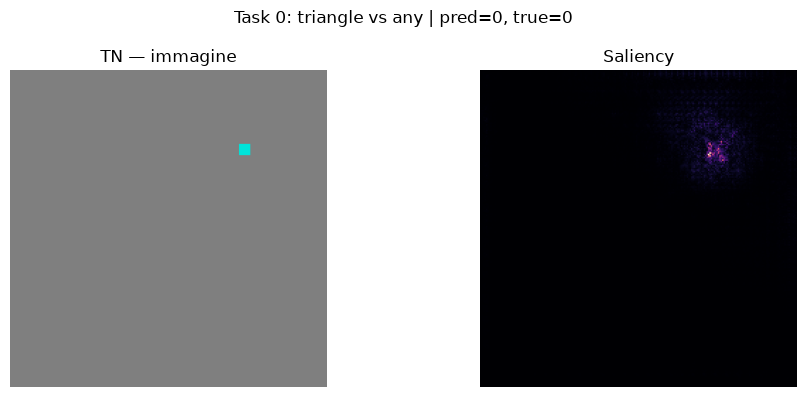

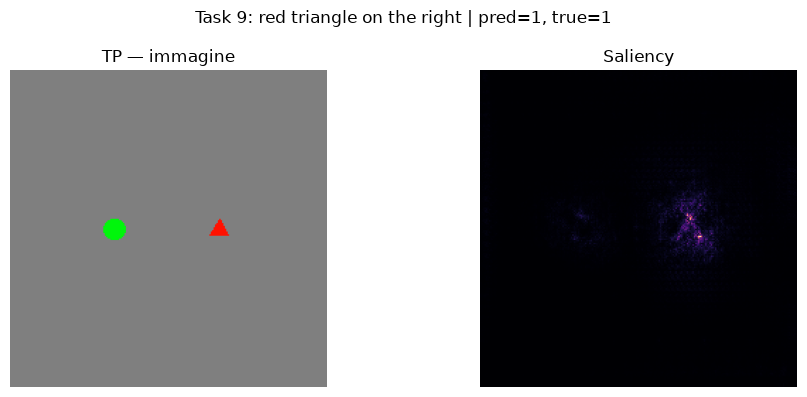

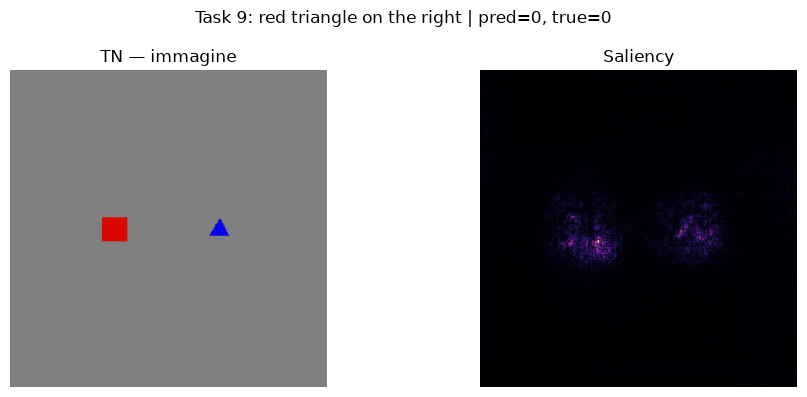

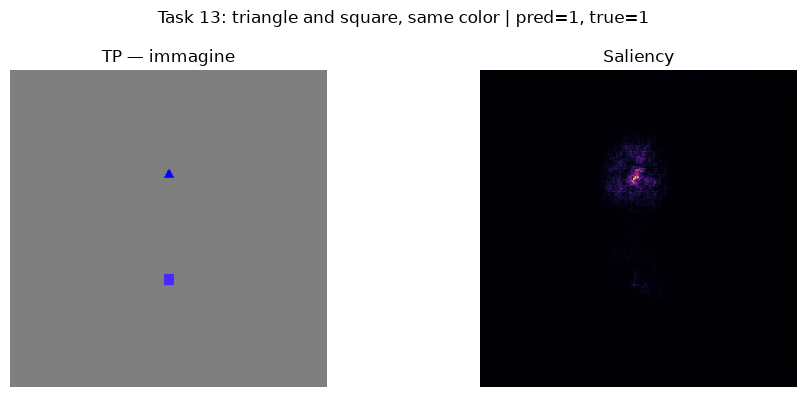

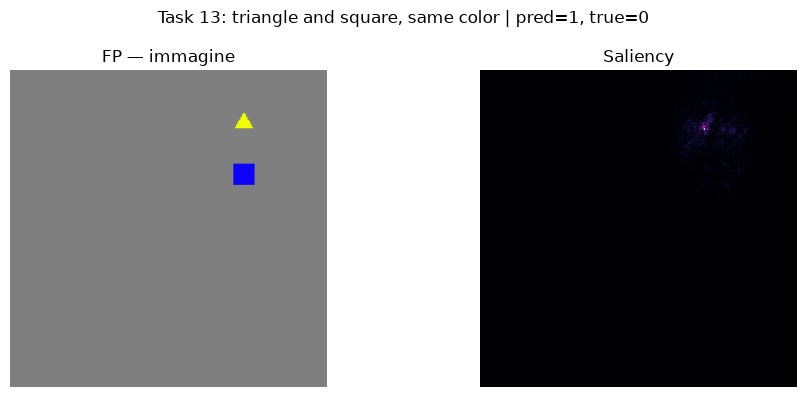

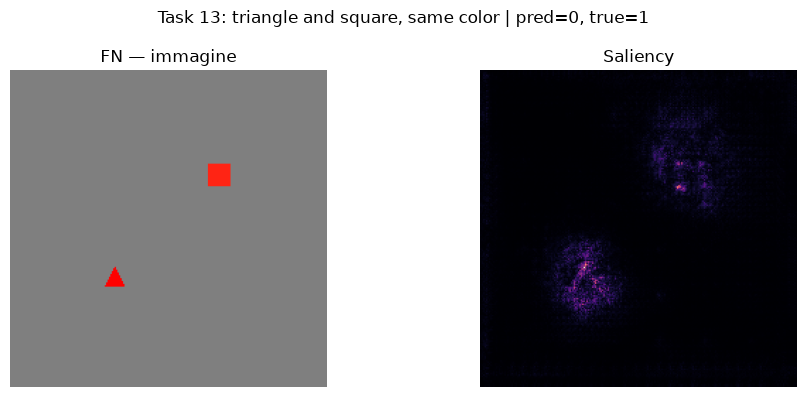

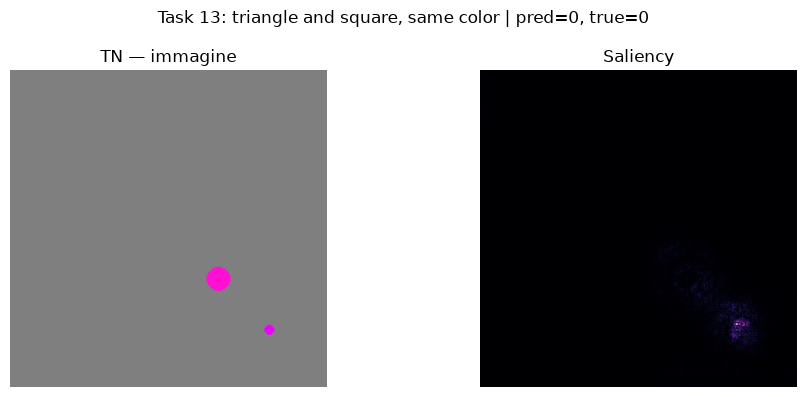

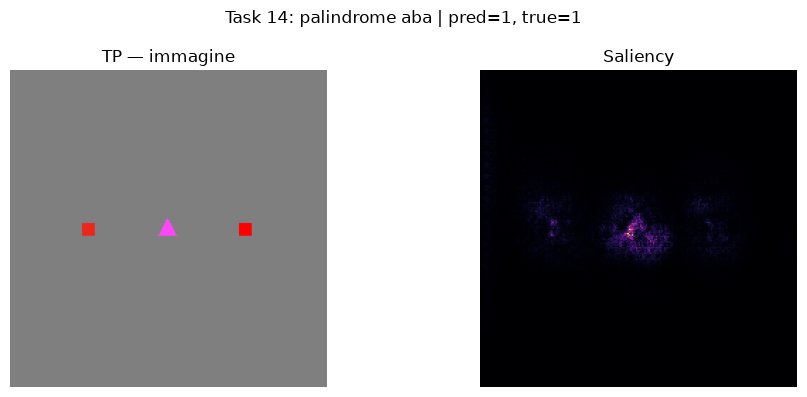

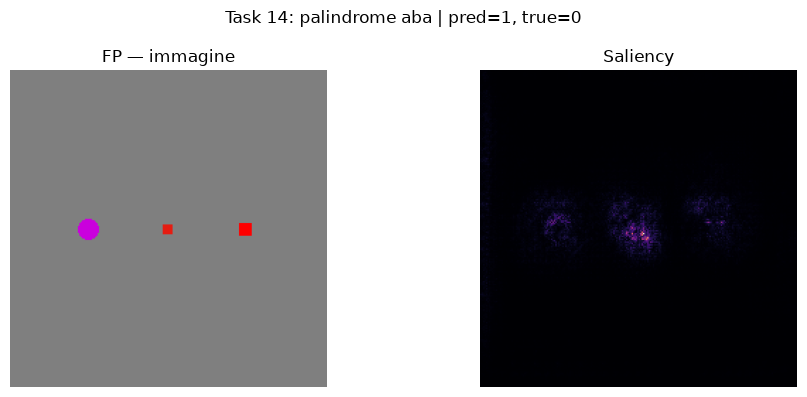

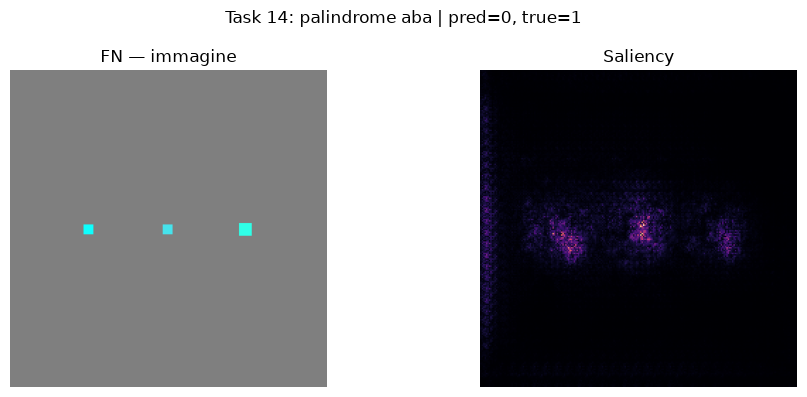

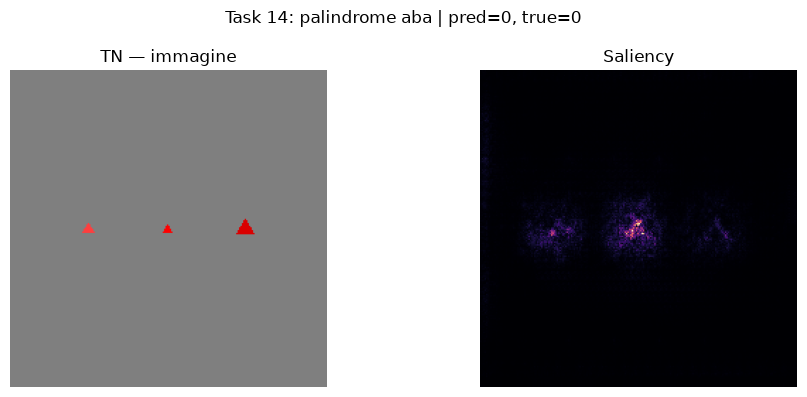

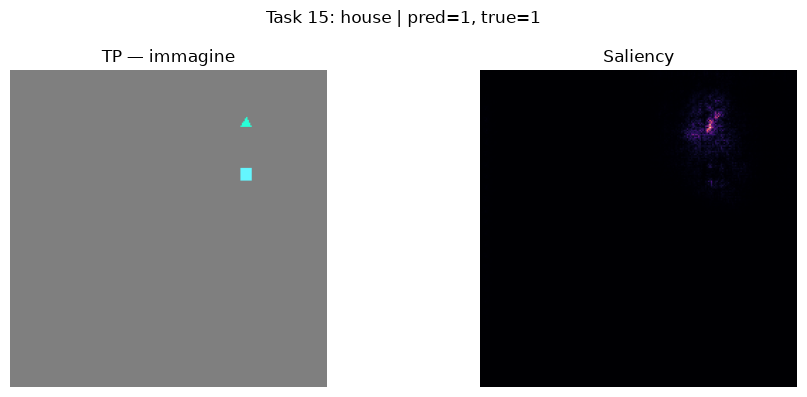

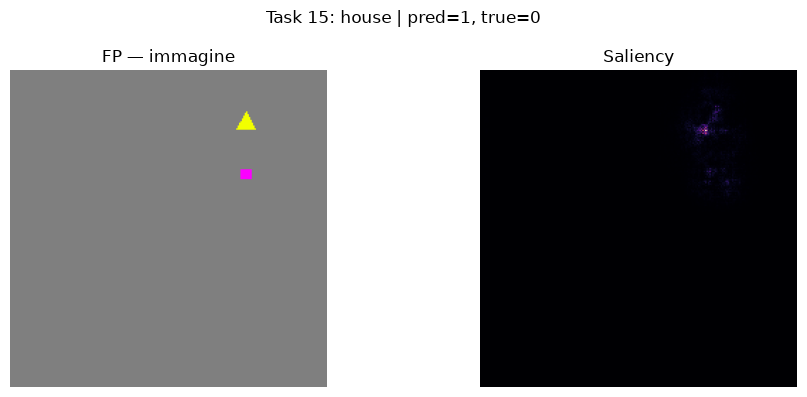

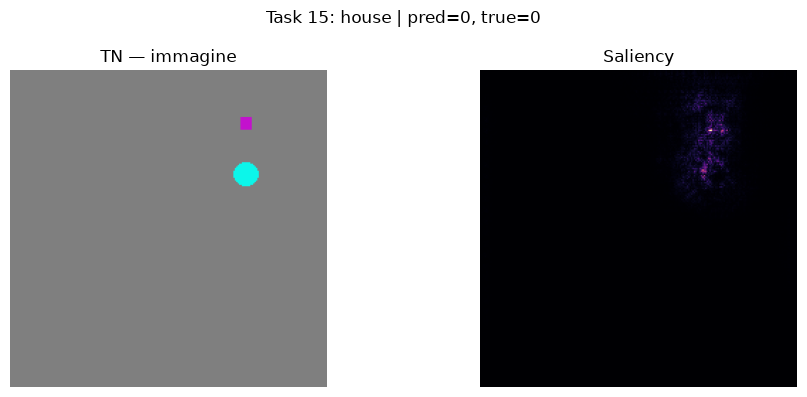

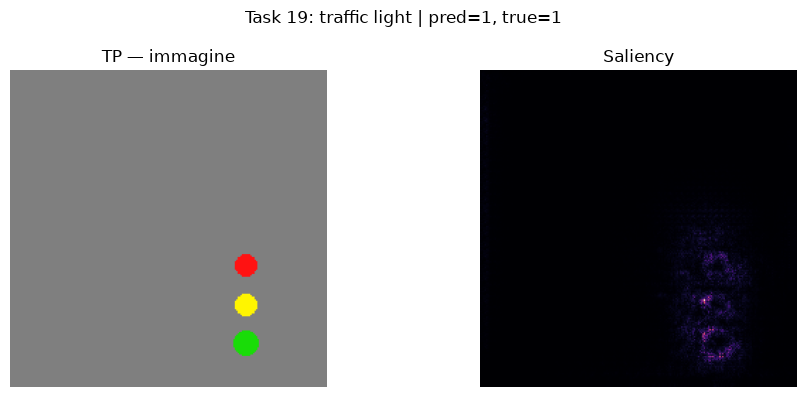

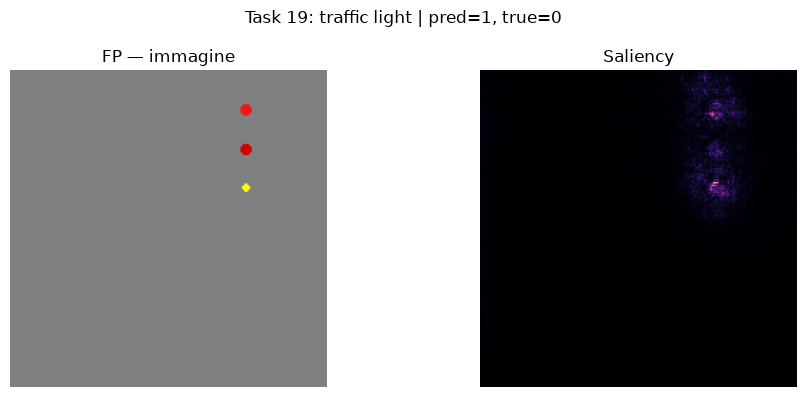

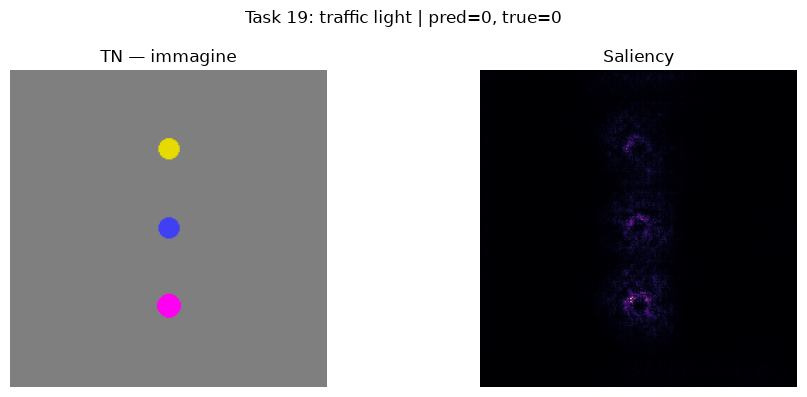

In [25]:
def preprocess_image_for_model(image):
    #applichiamo lo stesso preprocessing usato durante il training
    
    return eval_transform(image).unsqueeze(0).to(DEVICE)


def signed_task_logit(model, x, task_id, target_class):
    logits = model(x)
    #calcoliamo i logits prodotti dal modello
    
    score = logits[:, task_id]
    #selezioniamo il logit della task che vogliamo spiegare

    if target_class == 1:
        return score

    return -score
    #cambiamo il segno allo score in caso la classe sia negativa:
    #-x spinge verso 0 ma, se non cambiamo, spingerebbe lontano da 0


def compute_saliency(
    model,
    image,
    task_id,
    target_class,
):
    x = preprocess_image_for_model(
        image
    )

    x.requires_grad_(True)
    #abilitiamo il calcolo del gradiente rispetto all'input

    model.zero_grad(set_to_none=True)
    #azzeriamo i gradienti calcolati in precedenza

    score = signed_task_logit(
        model,
        x,
        task_id,
        target_class,
    )
    #calcoliamo lo score relativo alla classe da spiegare

    score.sum().backward()
    #calcoliamo il gradiente dello score rispetto all'immagine

    saliency = x.grad.detach().abs()
    #prendiamo il valore assoluto del gradiente

    saliency = saliency.max(dim=1).values[0]
    saliency = saliency.cpu().numpy()
    #aggreghiamo i tre canali rgb ottenendo una mappa 2d

    saliency -= saliency.min()
    max_value = saliency.max()
    #normalizziamo la mappa tra 0 e 1

    if max_value > 0:
        saliency /= max_value

    return saliency


saliency_records = []

selected_model.eval()
#mettiamo il modello in modalità eval()

for task_id, cases in XAI_CASES.items():
    #analizziamo le task e i casi scelti per l'analisi xai

    for case_name, row in cases.items():

        image = Image.open(
            TEST_DIR / row["filename"]
        ).convert("RGB")

        saliency = compute_saliency(
            selected_model,
            image,
            task_id,
            int(row["prediction"]),
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=tuple(CONFIG["xai"]["saliency_figsize"]),
        )

        axes[0].imshow(image)
        axes[0].set_title(
            f"{case_name} — immagine"
        )
        axes[0].axis("off")

        axes[1].imshow(
            saliency,
            cmap="magma",
        )
        axes[1].set_title(
            "Saliency"
        )
        axes[1].axis("off")

        fig.suptitle(
            f"Task {task_id}: {TASK_NAMES[task_id]} | "
            f"pred={int(row['prediction'])}, "
            f"true={int(row['true_label'])}"
        )

        plt.tight_layout()

        path = (
            SALIENCY_DIR
            / f"task_{task_id:02d}_{case_name}.png"
        )

        plt.savefig(
            path,
            dpi=int(CONFIG["xai"]["dpi"]),
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

        saliency_records.append({
            "task_id": task_id,
            "task": TASK_NAMES[task_id],
            "case": case_name,
            "filename": row["filename"],
            "prediction": int(row["prediction"]),
            "true_label": int(row["true_label"]),
            "mean_saliency": float(saliency.mean()),
            "max_saliency": float(saliency.max()),
            "path": str(path),
        })

saliency_df = pd.DataFrame(
    saliency_records
)

saliency_df.to_csv(
    XAI_DIR / "saliency_statistics.csv",
    index=False,
)

## Analisi dei Risultati

Le mappe mostrano che il modello tende a concentrarsi sugli oggetti rilevanti dell'immagine, anche nei casi in cui la predizione è errata, segno che il modello riesce a individuare le parti più importanti dell'immagine. Nei task più semplici la salienza è spesso molto localizzata, mentre nei task strutturati si distribuisce su più oggetti e lungo la loro configurazione. Nei casi FP e FN questo comportamento evidenzia un limite interessante: il modello riconosce spesso gli elementi visivi corretti, ma fatica a distinguere la relazione o la combinazione precisa richiesta dalla task.

Nelle mappe si nota inoltre una maggiore intensità dei gradienti lungo i contorni degli oggetti, mentre la parte interna rimane relativamente poco attiva. Questo comportamento è coerente con la natura di Vanilla Gradient: la misura evidenzia i pixel per i quali una piccola perturbazione modifica maggiormente l'output e siccome i nostri oggetti sintetici hanno regioni interne quasi uniformi e bordi molto netti, le variazioni lungo il contorno risultano particolarmente rilevanti.

Un risultato interessante che riguarda il task 9, “red triangle on the right” è il seguente: la saliency rimane attiva anche nella parte destra dell’immagine, anche in assenza di oggetti. Questo può indicare che il modello sfrutta anche l’informazione spaziale della scena nella decisione, dando importanza alla posizione in cui dovrebbe trovarsi l’oggetto richiesto

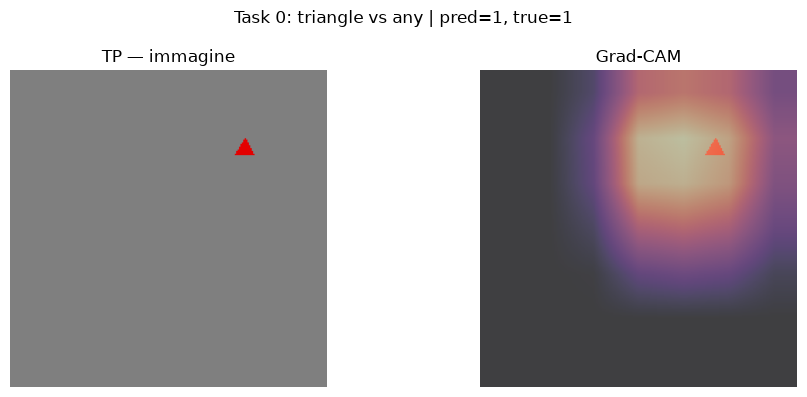

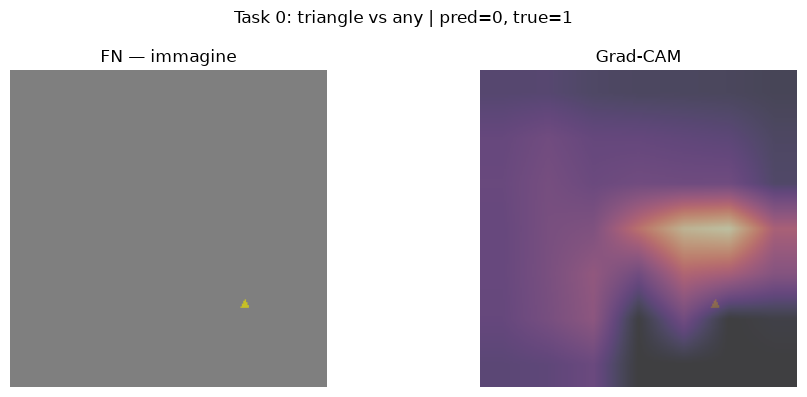

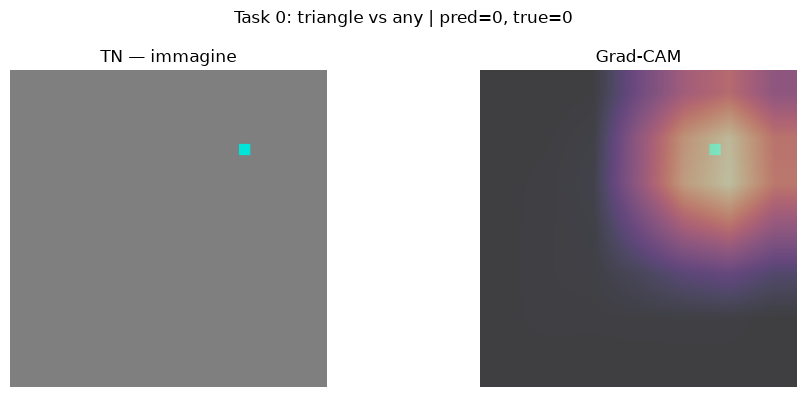

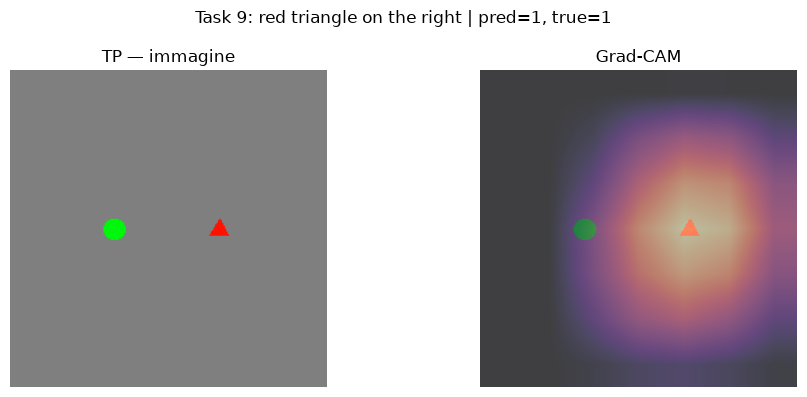

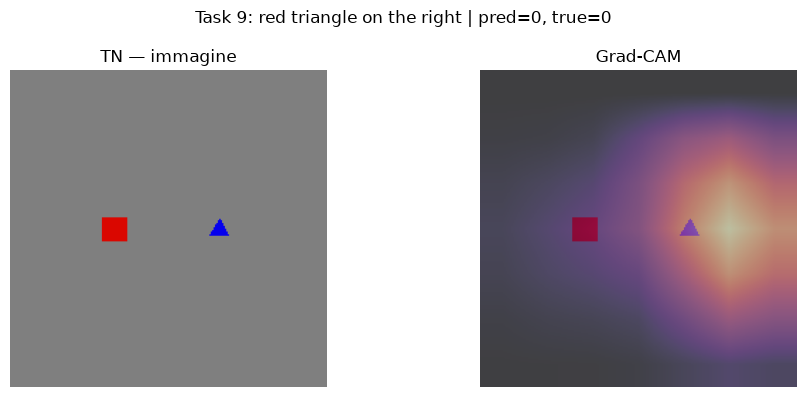

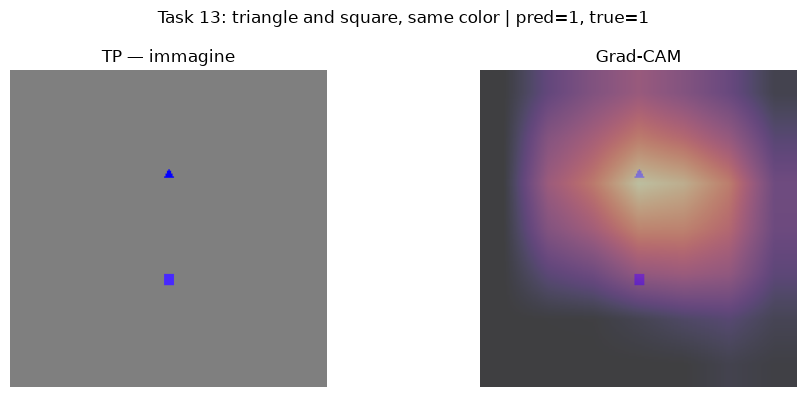

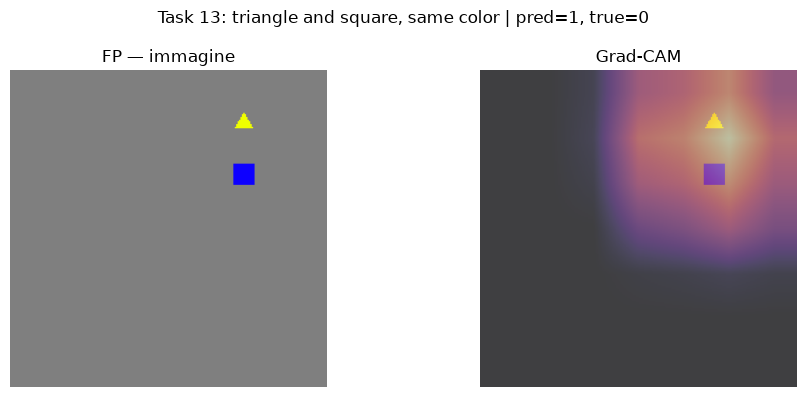

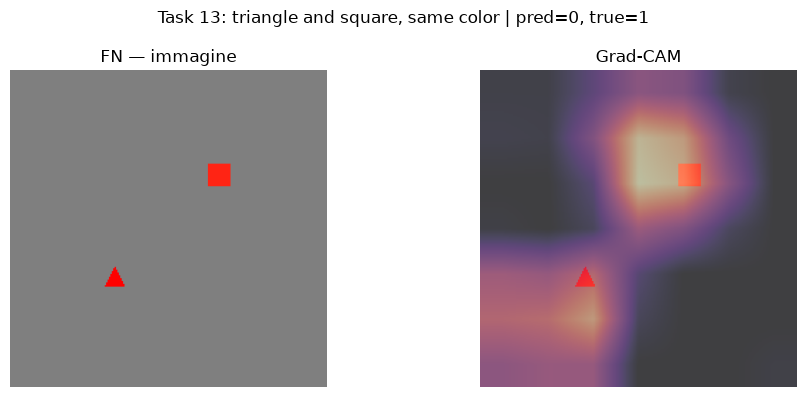

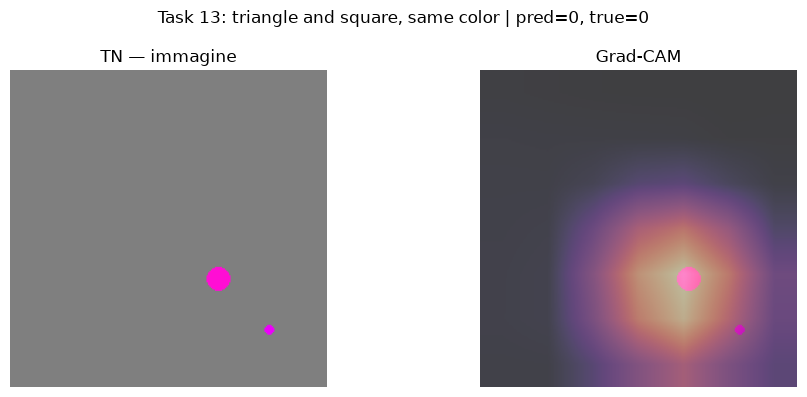

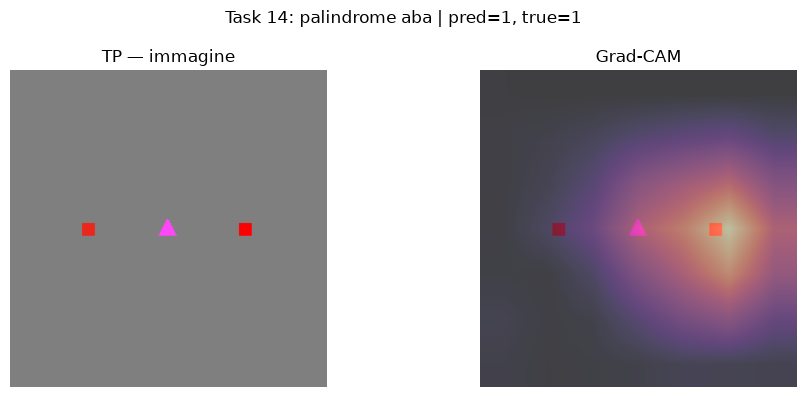

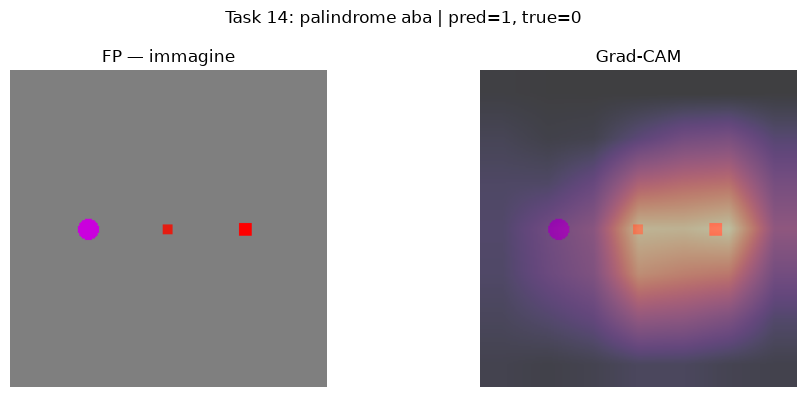

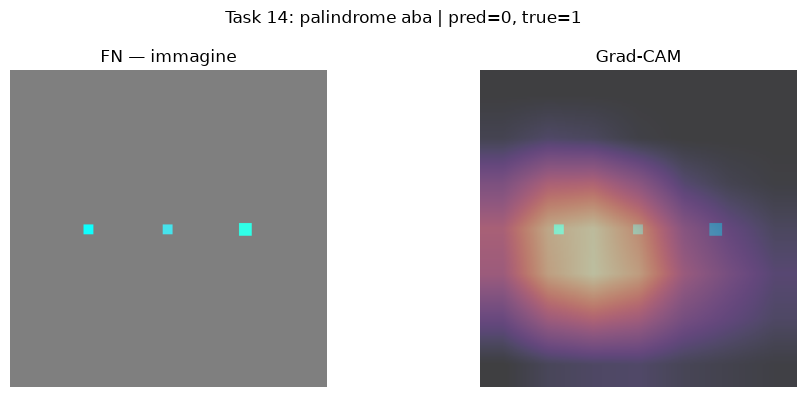

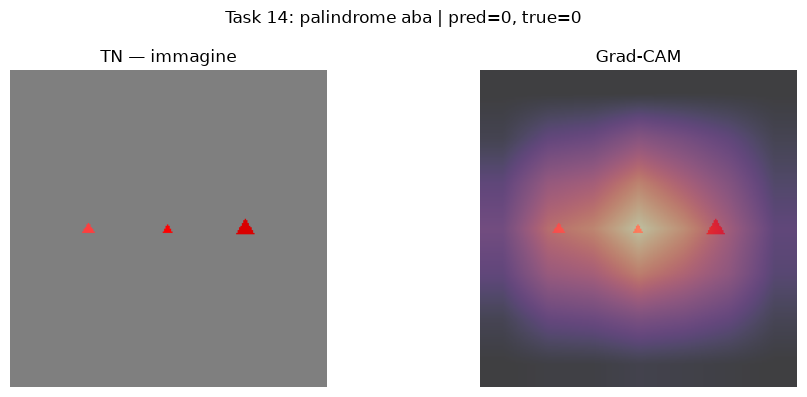

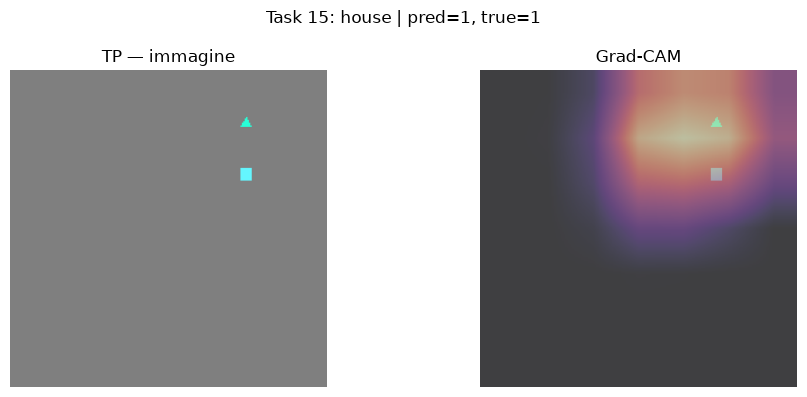

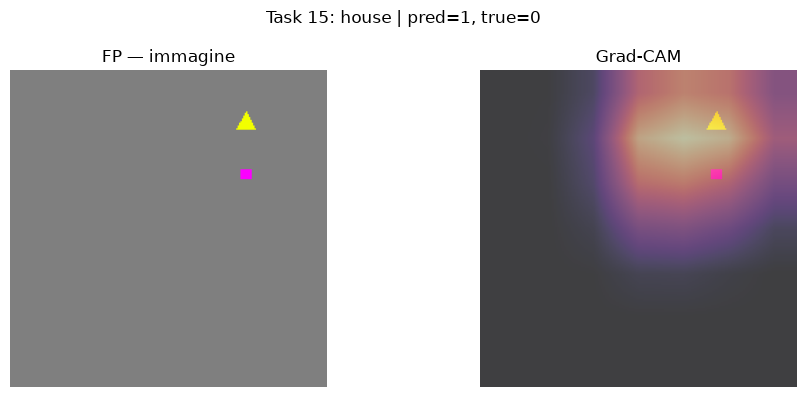

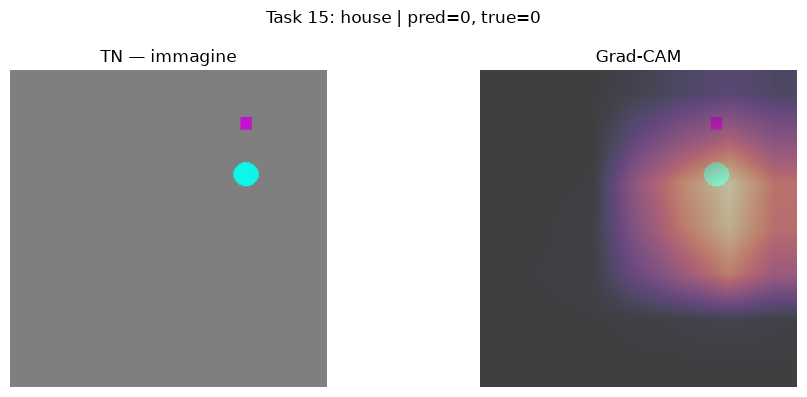

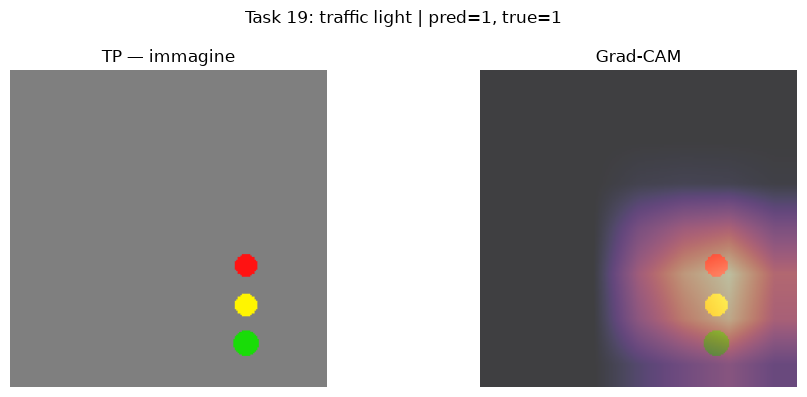

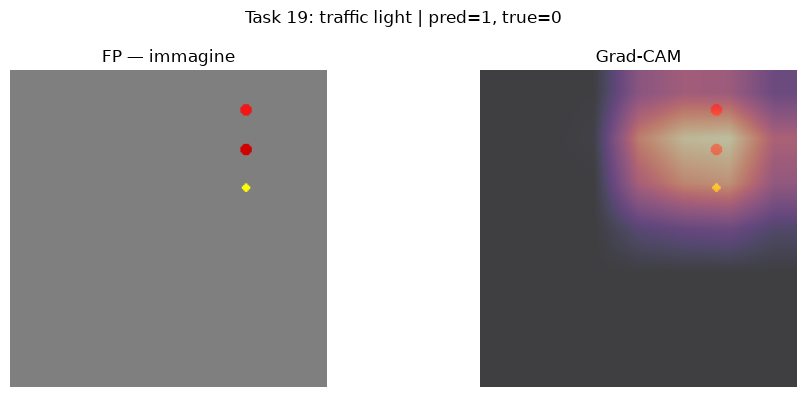

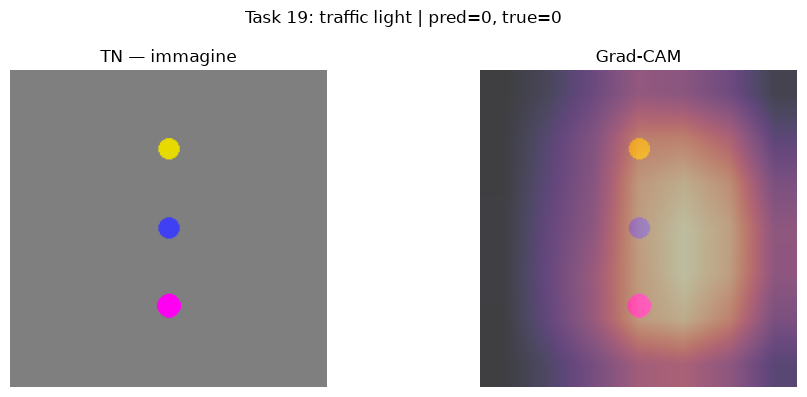

In [26]:
#GRADCAM

def compute_gradcam(
    model,
    image,
    task_id,
    target_class,
):
    
    target_layer = model.backbone.layer4[-1]
    #estraiamo il layer convoluzionale finale

    activations = []
    gradients = []

    def forward_hook(module, inputs, output):
        activations.append(output)
        #salviamo le attivazioni

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
        #salviamo i gradienti

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    x = preprocess_image_for_model(image)

    x.requires_grad_(True)

    model.zero_grad(set_to_none=True)

    logits = model(x)
    #otteniamo i logits dei task

    score = logits[:, task_id]

    if target_class == 1:
        score = score
    else:
        score = -score
        #scegliamo la direzione della classe che vogliamo spiegare

    score.sum().backward()
    #calcoliamo i gradienti rispetto al layer

    activation = activations[0].detach()
    gradient = gradients[0].detach()

    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True,
    )
    #calcoliamo il peso medio di ogni feature map

    cam = (
        weights * activation
    ).sum(dim=1)
    #combiniamo le feature map con i pesi ottenuti prima

    cam = torch.relu(cam)
    #manteniamo solo i contributi positivi

    cam = F.interpolate(
        cam.unsqueeze(1),
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False,
    ).squeeze()
    #riportiamo la mappa alla dimensione dell'immagine

    cam = cam.cpu().numpy()

    cam -= cam.min()

    max_value = cam.max()

    if max_value > 0:
        cam /= max_value
        #normalizziamo la mappa tra 0 e 1

    # rimuoviamo gli hook dopo l'uso
    forward_handle.remove()
    backward_handle.remove()

    return cam


gradcam_records = []

selected_model.eval()

for task_id, cases in XAI_CASES.items():
    for case_name, row in cases.items():

        image = Image.open(
            TEST_DIR / row["filename"]
        ).convert("RGB")

        cam = compute_gradcam(
            selected_model,
            image,
            task_id,
            int(row["prediction"]),
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=tuple(CONFIG["xai"]["gradcam_figsize"]),
        )

        axes[0].imshow(image)
        axes[0].set_title(
            f"{case_name} — immagine"
        )
        axes[0].axis("off")

        axes[1].imshow(image)
        axes[1].imshow(
            cam,
            cmap="magma",
            alpha=0.5,
        )
        axes[1].set_title(
            "Grad-CAM"
        )
        axes[1].axis("off")

        fig.suptitle(
            f"Task {task_id}: {TASK_NAMES[task_id]} | "
            f"pred={int(row['prediction'])}, "
            f"true={int(row['true_label'])}"
        )

        plt.tight_layout()

        path = (
            XAI_DIR / "gradcam"
            / f"gradcam_task_{task_id:02d}_{case_name}.png"
        )

        plt.savefig(
            path,
            dpi=int(CONFIG["xai"]["dpi"]),
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

        gradcam_records.append({
            "task_id": task_id,
            "task": TASK_NAMES[task_id],
            "case": case_name,
            "filename": row["filename"],
            "prediction": int(row["prediction"]),
            "true_label": int(row["true_label"]),
            "mean_gradcam": float(cam.mean()),
            "max_gradcam": float(cam.max()),
            "path": str(path),
        })


gradcam_df = pd.DataFrame(
    gradcam_records
)

gradcam_df.to_csv(
    XAI_DIR / "gradcam_statistics.csv",
    index=False,
)

## Analisi dei risultati

Grad-cam mostra una localizzazione più compatta rispetto a vanilla gradient. Nei task semplici l'attivazione si concentra soprattutto sull'oggetto rilevante, mentre nei task strutturati si distribuisce su più oggetti e sulla loro configurazione spaziale, in particolare:

- il task 9 si concentra sulla parte destra dell'immagine
- il task 13 evidenzia entrambi gli oggetti coinvolti nella relazione,
- il task 14 considera l'intera sequenza
- il task 19 segue chiaramente la struttura verticale del semaforo

Nei casi di errore il modello individua spesso le regioni corrette, ma non sempre riesce a distinguere la relazione o la combinazione precisa richiesta dal task.

## SHAP

Provo adesso a utilizzare SHAP sugli stessi casi analizzati precedentemente; il background viene costruito con alcune immagini del training set della stessa task, così la spiegazione rimane legata alla distribuzione del task che stiamo analizzando.

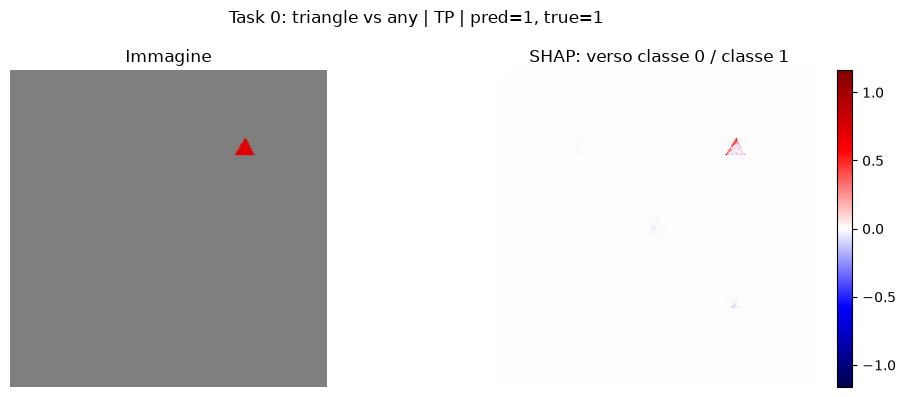

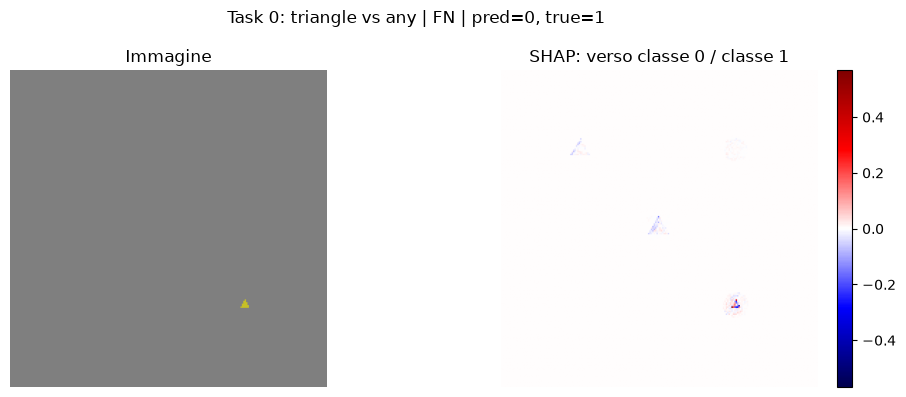

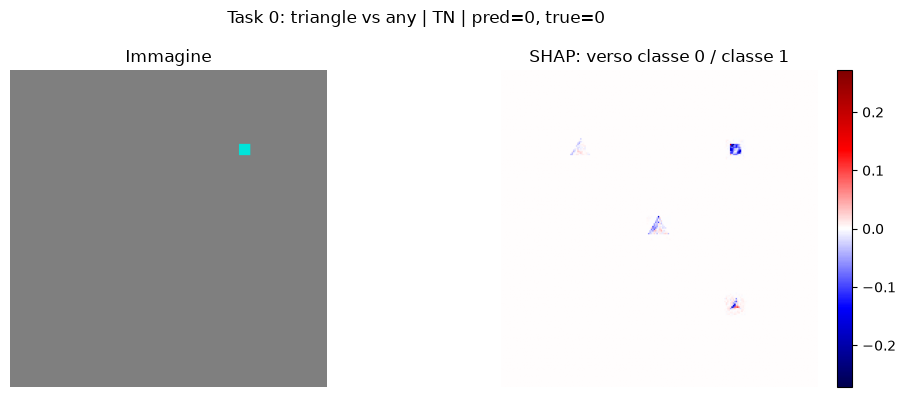

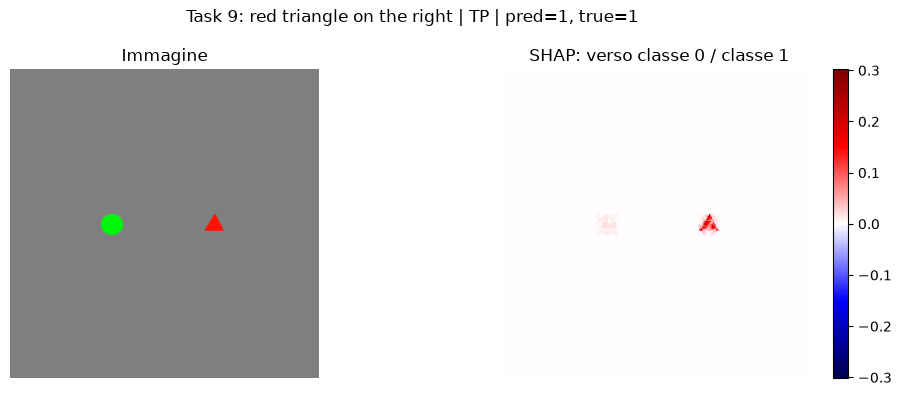

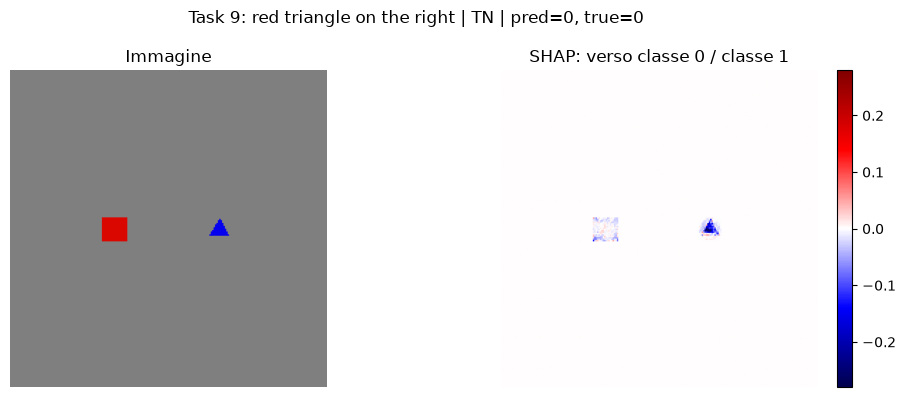

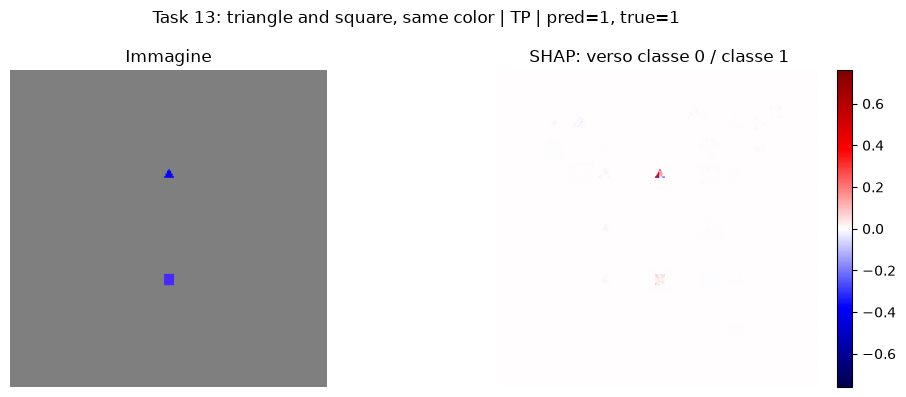

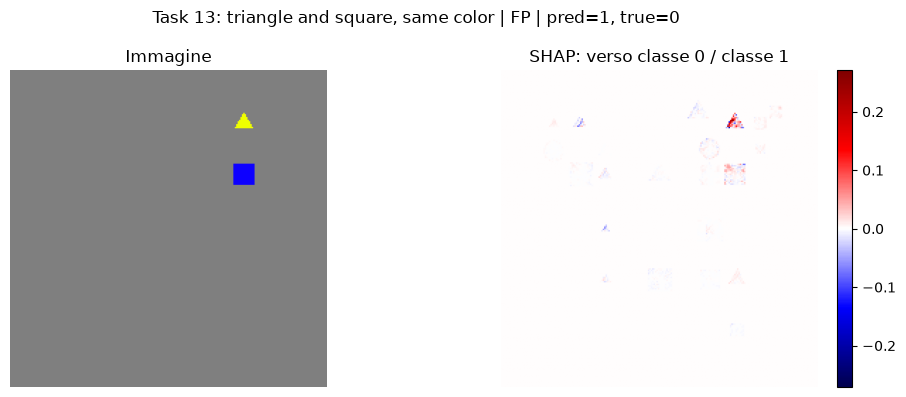

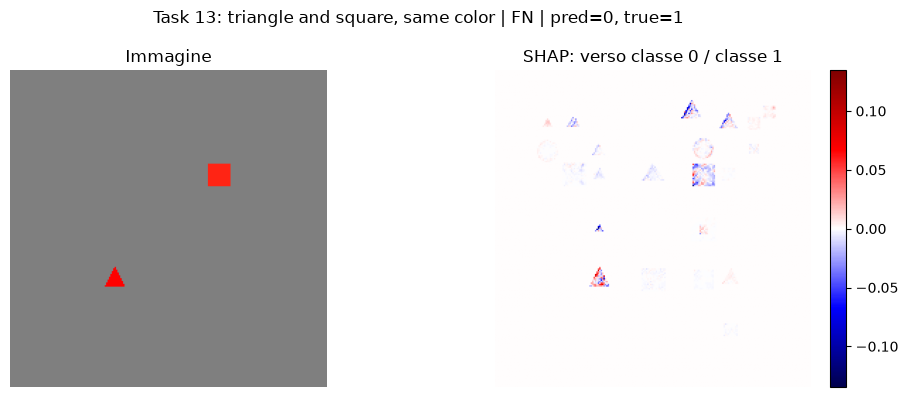

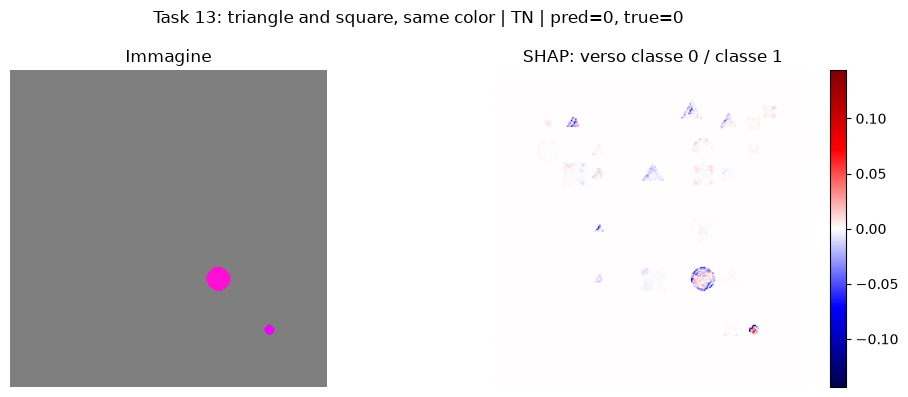

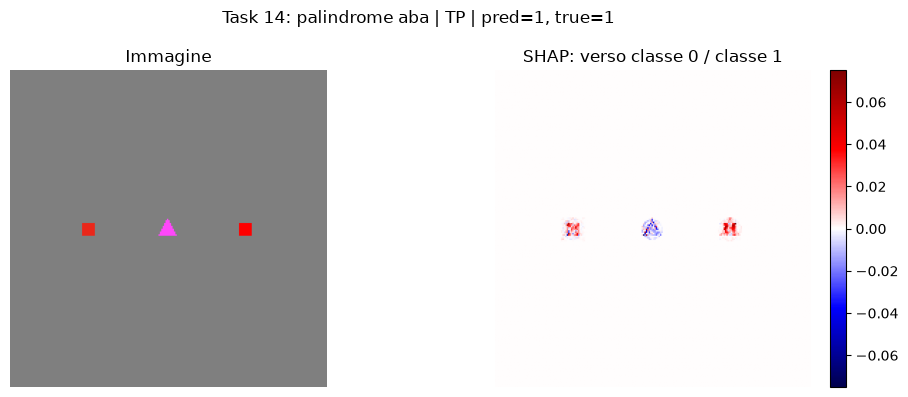

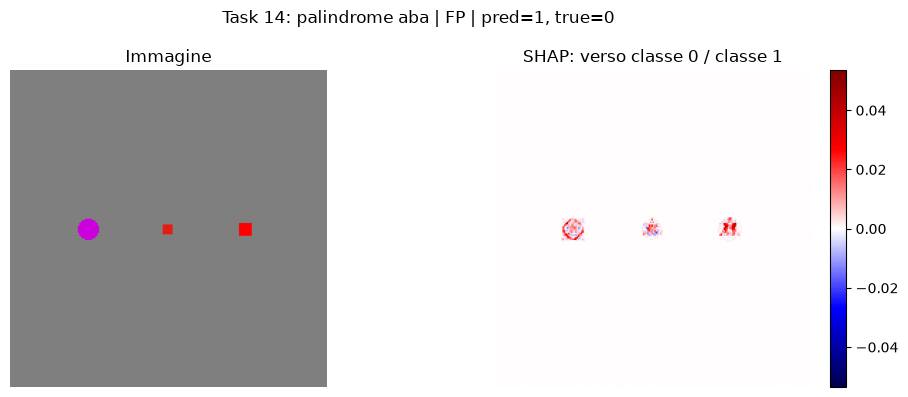

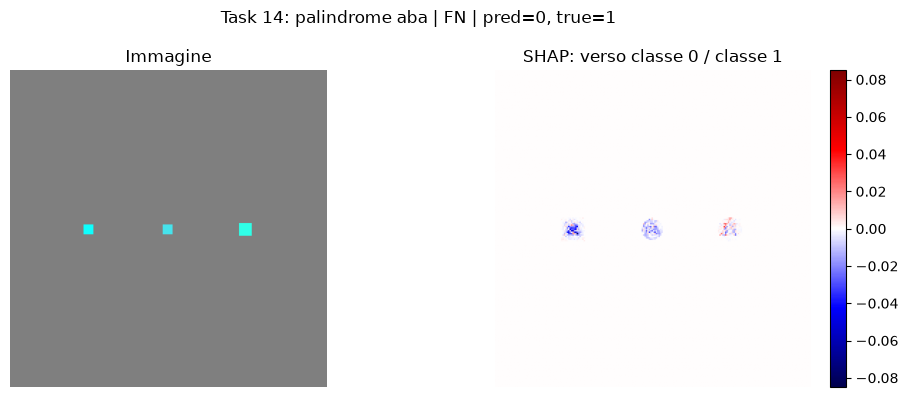

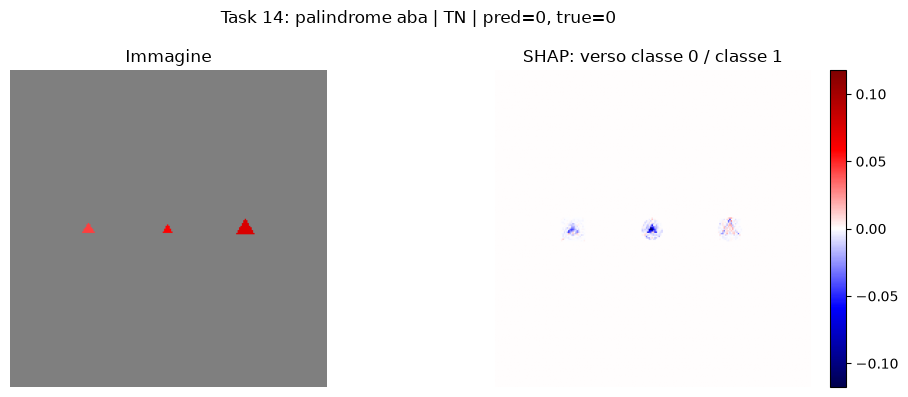

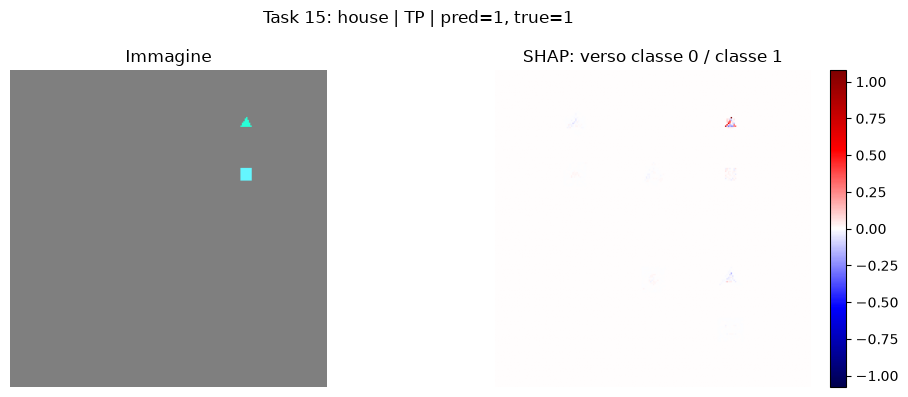

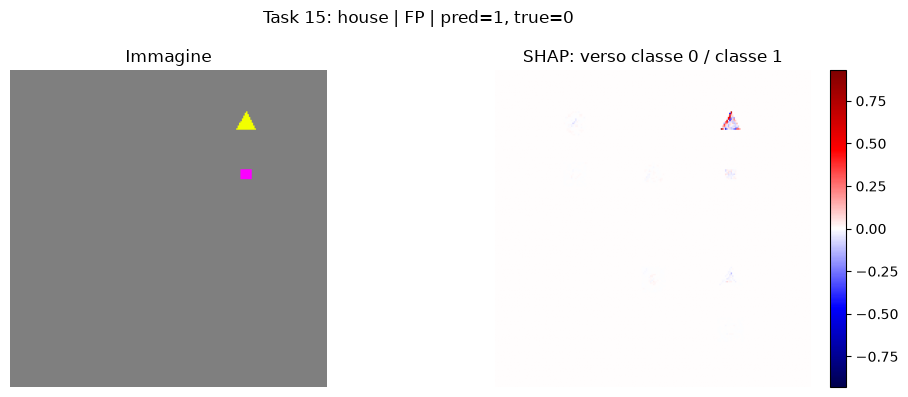

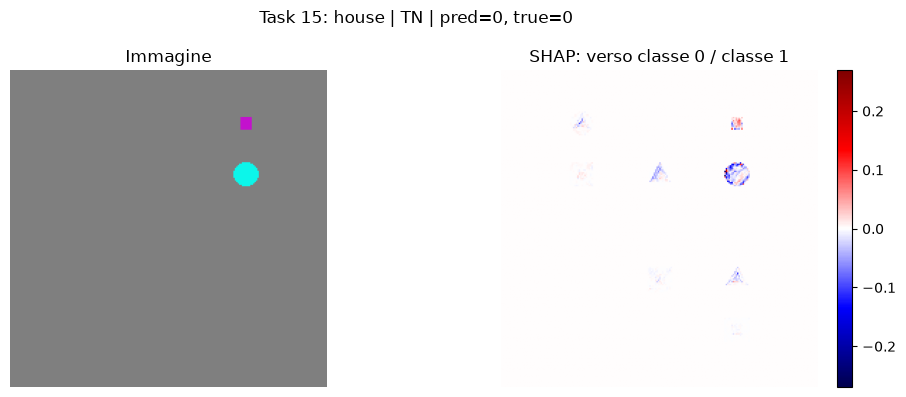

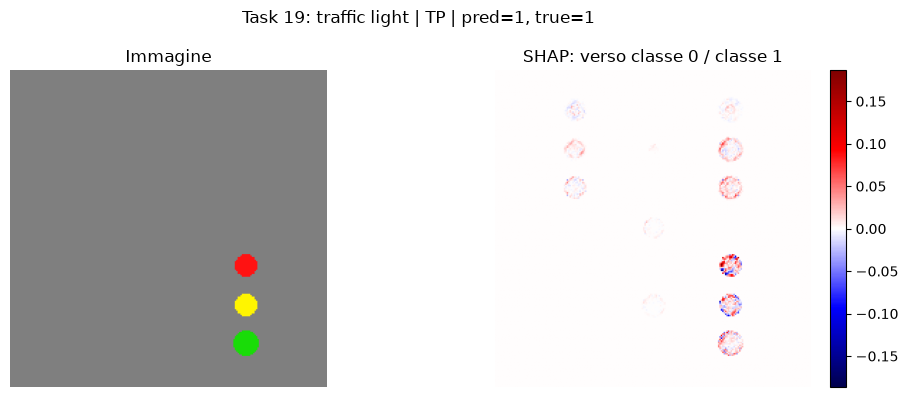

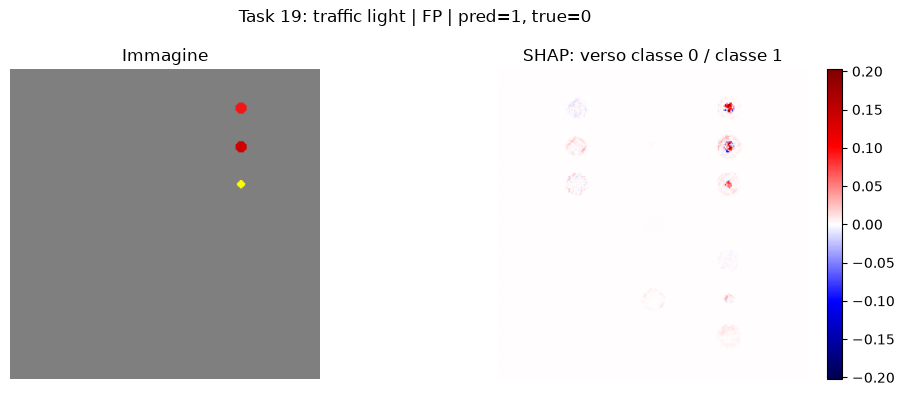

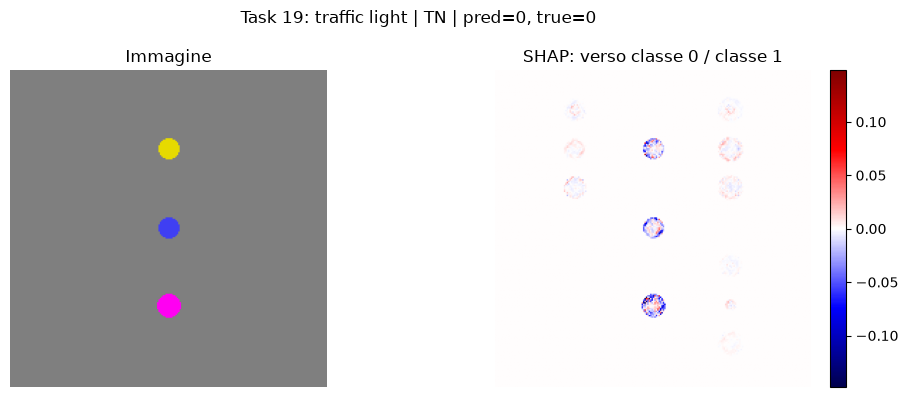

In [27]:
#SHAP

def build_background(task_id, n_background=None):
    #costruiamo il background in base alla quale l'explainer andrà a calcolare le attribuzioni
    
    if n_background is None:
        n_background = int(
            CONFIG["xai"]["shap_background_samples"]
        )
    #numero di immagini usate come background per SHAP

    task_train = train_all[
        train_all["task_id"] == task_id
    ]

    rows = task_train.sample(
        n=min(n_background, len(task_train)),
        random_state=SEED,
    )

    tensors = []

    for _, row in rows.iterrows():
        image = Image.open(
            TRAIN_DIR / row["filename"]
        ).convert("RGB")

        tensors.append(
            eval_transform(image)
        )

    return torch.stack(
        tensors
    ).to(DEVICE)


class TaskLogitWrapper(nn.Module):
    #restituisce il logit del task selezionato:
    #SHAP > 0  -> spinge verso la classe 1
    #SHAP < 0  -> spinge verso la classe 0
    
    def __init__(self, model, task_id):
        super().__init__()
        self.model = model
        self.task_id = task_id

    def forward(self, x):
        logits = self.model(x)

        return logits[
            :,
            self.task_id:self.task_id + 1
        ]


shap_records = []

for task_id, cases in XAI_CASES.items():

    background = build_background(
        task_id
    )

    for case_name, row in cases.items():

        wrapper = TaskLogitWrapper(
            selected_model,
            task_id,
        ).to(DEVICE)

        wrapper.eval()

        explainer = shap.GradientExplainer(
            wrapper,
            background,
        )
        #utilizziamo il gradientexplainer di shap:
        #l'obbiettivo è ottenere sempre una decomposizione con shapley values
        #ma, in questo caso, senza sfruttare le coalizioni;
        #in questo caso si utilizza il metodo del gradiente atteso
        #in cui si considerano i gradienti lungo il percorso tra il background e l'immagine da spiegare
        #  si aggregano questi contributi per ottenere una stima degli shapley values

        image = Image.open(
            TEST_DIR / row["filename"]
        ).convert("RGB")

        x = eval_transform(
            image
        ).unsqueeze(0).to(DEVICE)

        shap_values = explainer.shap_values(x)

        if isinstance(shap_values, list):
            values = np.asarray(
                shap_values[0]
            )
        else:
            values = np.asarray(
                shap_values
            )

        values = np.squeeze(values)

        #C,H,W -> H,W
        #manteniamo il segno, non usiamo np.abs()
        if values.ndim == 3:
            values = values.sum(axis=0)

        elif values.ndim != 2:
            raise ValueError(
                f"Forma SHAP inattesa: {values.shape}"
            )

        vmax = np.max(
            np.abs(values)
        )

        if vmax > 0:
            vmin = -vmax
        else:
            default_range = float(
                CONFIG["xai"]["shap_default_range"]
            )
            vmin = -default_range
            vmax = default_range


        fig, axes = plt.subplots(
            1,
            2,
            figsize=tuple(CONFIG["xai"]["shap_figsize"]),
        )

        axes[0].imshow(image)
        axes[0].set_title("Immagine")
        axes[0].axis("off")

        im = axes[1].imshow(
            values,
            cmap="seismic",
            vmin=vmin,
            vmax=vmax,
        )

        axes[1].set_title(
            "SHAP: verso classe 0 / classe 1"
        )
        axes[1].axis("off")
        fig.colorbar(
            im,
            ax=axes[1],
            fraction=float(CONFIG["xai"]["shap_colorbar_fraction"]),
            pad=float(CONFIG["xai"]["shap_colorbar_pad"]),
        )

        fig.suptitle(
            f"Task {task_id}: {TASK_NAMES[task_id]} | "
            f"{case_name} | "
            f"pred={int(row['prediction'])}, "
            f"true={int(row['true_label'])}"
        )

        plt.tight_layout()

        path = (
            SHAP_DIR
            / f"task_{task_id:02d}_{case_name}.png"
        )

        plt.savefig(
            path,
            dpi=int(CONFIG["xai"]["dpi"]),
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

        shap_records.append({
            "task_id": task_id,
            "task": TASK_NAMES[task_id],
            "case": case_name,
            "filename": row["filename"],
            "prediction": int(row["prediction"]),
            "true_label": int(row["true_label"]),
            "path": str(path),
        })


pd.DataFrame(
    shap_records
).to_csv(
    XAI_DIR / "shap_selected_cases.csv",
    index=False,
)

## Analisi dei risultati

Le mappe SHAP mostrano contributi generalmente più localizzati sugli oggetti rispetto alla Vanilla Gradient. Nei task semplici le attribuzioni si concentrano soprattutto sull'oggetto rilevante, mentre nei task più strutturati coinvolgono più elementi della scena. In particolare, nel task 14 vengono attribuiti contributi ai tre oggetti della sequenza, mentre nel task 19 le attribuzioni seguono chiaramente la struttura verticale del semaforo. Nei casi di errore il modello continua spesso a evidenziare gli oggetti corretti dal punto di vista visivo, ma assegna loro contributi nella direzione sbagliata o non sufficienti a ottenere la classe corretta.

Le "ombre" che compaiono attorno agli oggetti e sullo sfondo derivano dal confronto con il background SHAP e dalla propagazione dei gradienti nelle feature convoluzionali, e rappresentano contributi deboli rispetto alle regioni più attive.

## Collegamento col Concept Bottleneck Model

Alla fine del confronto abbiamo un encoder selezionato sulla validation e un checkpoint completo del modello multi-task, nel notebook 4 non ci interesserà riutilizzare le 20 teste di classificazione: ci interessa soprattutto l'encoder visivo condiviso.

Per questo salviamo anche la configurazione scelta e il checkpoint, così il modulo visivo può essere inizializzato nel Concept Bottleneck Model senza dover ripetere il benchmark.

In [28]:
#SALVATAGGIO BACKBONE

if "selected_variant" not in globals():

    selected_variant = results_df.loc[
        results_df["val_f1"].idxmax(),
        "variant",
    ]
    #scegliamo la configurazione con la f1 migliore sul validation set

print("Modello selezionato:", selected_variant)


selected_model = build_multitask_model(
    selected_variant
).to(DEVICE)

#ricostruiamo l'architettura del modello e carichiamo il miglior checkpoint

full_checkpoint_path = (
    CHECKPOINT_DIR
    / f"{selected_variant}_best.pt"
)
#ricostruiamo il modello con la stessa architettura usata nel training

checkpoint = torch.load(
    full_checkpoint_path,
    map_location=DEVICE,
    weights_only=False,
)
#carichiamo i pesi salvati del modello

selected_model.load_state_dict(
    checkpoint["model_state_dict"]
)
#inseriamo nel modello i pesi imparati durante il training

selected_model.eval()

print(
    "Checkpoint caricato:",
    full_checkpoint_path,
)

encoder_state = {
    key[len("backbone."):]: value.cpu()
    for key, value in selected_model.state_dict().items()
    if key.startswith("backbone.")
}
#selezioniamo solo i parametri del backbone e rimuoviamo il prefisso "backbone."

encoder_path = (
    CHECKPOINT_DIR
    / f"{selected_variant}_encoder_only.pt"
)

torch.save(
    {
        "variant": selected_variant,
        "task_ids": TASK_IDS,
        "image_size": IMAGE_SIZE,
        "encoder_state_dict": encoder_state,
        "seed": SEED,
    },
    encoder_path,
)
#salviamo i pesi dell'encoder insieme alle informazioni necessarie


selected_val_f1 = results_df.loc[
    results_df["variant"] == selected_variant,
    "val_f1",
].iloc[0]

final_config = {
    "selected_variant": selected_variant,
    "validation_f1": float(selected_val_f1),
    "encoder_checkpoint": str(
        encoder_path
    ),
    "full_checkpoint": str(
        full_checkpoint_path
    ),
    "tasks": TASK_IDS,
}

with open(
    RESULTS_DIR / "visual_encoder_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        final_config,
        f,
        indent=2,
    )
#salviamo queste informazioni in un file json

print(
    "Encoder salvato:",
    encoder_path,
)

print(
    f"Validation F1: {selected_val_f1:.4f}"
)
# mostriamo la f1 della configurazione selezionata

Modello selezionato: resnet18_pretrained
Checkpoint caricato: /home/cosimo/Downloads/kandy-xai/results/visual_models/checkpoints/resnet18_pretrained_best.pt
Encoder salvato: /home/cosimo/Downloads/kandy-xai/results/visual_models/checkpoints/resnet18_pretrained_encoder_only.pt
Validation F1: 0.9229


## Conclusione

Il confronto tra i diversi encoder mostra che le architetture pretrained ottengono risultati migliori rispetto alle versioni addestrate da zero, con la ResNet-18 pretrained che raggiunge in validation un F1 medio di 0.899. Per questo motivo è stata scelta come encoder per le analisi successive. 

Le spiegazioni post-hoc permettono poi di capire meglio come il modello prende le decisioni: la Vanilla Gradient evidenzia soprattutto la sensibilità locale e i contorni, la Grad-CAM mostra le regioni più rilevanti nelle feature profonde, mentre SHAP permette di analizzare i contributi positivi e negativi rispetto a un insieme di immagini di riferimento. Nel complesso, queste analisi mostrano che il modello individua correttamente molte delle regioni rilevanti, ma nei task più strutturati tende a utilizzare informazioni più distribuite e può confondere configurazioni visivamente simili.